# **🧩 Problem Discovery & Solution Framing (Checklist 1)**

Tahap ini bertujuan untuk mengidentifikasi permasalahan utama dalam konteks pendidikan serta merumuskan solusi berbasis data yang relevan, terukur, dan berdampak.

## **🗺️ Problem Statement**

Penurunan performa akademik siswa sering kali tidak terdeteksi sejak dini karena kurangnya sistem pemantauan terintegrasi yang mampu menggabungkan berbagai faktor seperti kehadiran, kebiasaan belajar, motivasi, dan kondisi sosial ekonomi.
Akibatnya, intervensi dari pendidik cenderung bersifat reaktif dan terlambat, sehingga mengurangi efektivitas dalam membantu siswa yang berisiko.

## **💡 Solusi yang Diusulkan**

**EduPredict AI** merupakan platform berbasis *machine learning* yang dirancang untuk memprediksi risiko akademik siswa ke dalam tiga kategori: **Rendah, Sedang, dan Tinggi**, berdasarkan 20 variabel dari dataset *Student Performance Factors*.

Sistem ini dilengkapi dengan:
- Model klasifikasi berbasis *Neural Network (TensorFlow)*
- Dashboard interaktif untuk monitoring siswa
- Rekomendasi intervensi berbasis faktor risiko dominan

## **✨ Alasan Pemilihan Solusi**

Solusi ini dipilih karena:
- Menggunakan pendekatan **data-driven early warning system**
- Mampu mengintegrasikan berbagai faktor akademik dan non-akademik
- Memberikan output yang **actionable** bagi tenaga pendidik

## **🔬 Research Questions**

- **RQ1:** Sejauh mana faktor gaya hidup, kehadiran, dan akses teknologi memengaruhi risiko akademik siswa?

- **RQ2:** Seberapa baik model *Neural Network* dalam mengklasifikasikan risiko akademik siswa berdasarkan fitur yang tersedia?

## **🎯 Target Kinerja Model**

Akurasi ≥ **85%** dan MAE **0.02** dengan metrik evaluasi tambahan Precision, Recall, dan F1-Score untuk memastikan keseimbangan performa antar kelas

# **🧹 Data Wrangling (Checklist 2)**
Data *Wrangling* merupakan serangkaian proses yang terdiri dari data *gathering* (pengumpulan dan validasi data), data *assesing* (menilai dan melihat kualitas data) dan data *cleaning* (pembersihan data) agar data tersebut dapat ditarik *insight* penting didalamnya.

## **📦 Data Gathering**
Tahap ini bertujuan untuk memuat dataset ke dalam *environment Google Colab* agar dapat dianalisis lebih lanjut.

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

file_path = "StudentPerformanceFactors.csv"

# Load data
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "lainguyn123/student-performance-factors",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_244/4196973046.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-performance-factors' dataset.
First 5 records:    Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65         

## **📖 Data Dictionary (Checklist 6)**
Berikut adalah penjelasan dari setiap variabel (kolom) dalam dataset
*Student Performance Factors* yang digunakan dalam proyek EduPredict AI.
Dataset ini terdiri dari **6.607 baris** dan **20 kolom fitur**
dengan 1 kolom target tambahan (`Risk_Category`) yang dibuat pada
tahap Data Cleaning.


### **Fitur Numerik**

| Kolom | Tipe | Rentang | Deskripsi |
|---|---|---|---|
| `Hours_Studied` | int64 | 1–44 (asli), 4–36 (setelah capping) | Jumlah jam belajar siswa per minggu di luar jam sekolah formal |
| `Attendance` | int64 | 60–100 | Persentase kehadiran siswa di kelas (%) |
| `Sleep_Hours` | int64 | 4–10 | Rata-rata jam tidur siswa per malam |
| `Previous_Scores` | int64 | 50–100 | Nilai ujian atau rapor dari periode sebelumnya |
| `Tutoring_Sessions` | int64 | 0–8 (asli), 0–3 (setelah capping) | Jumlah sesi bimbingan belajar (les) yang diikuti per bulan |
| `Physical_Activity` | int64 | 0–6 | Jumlah jam aktivitas fisik per minggu |
| `Exam_Score` | int64 | 55–100 | Nilai ujian akhir siswa — digunakan sebagai dasar pembuatan label target |


### **Fitur Kategorikal**

| Kolom | Tipe | Nilai Unik | Deskripsi |
|---|---|---|---|
| `Parental_Involvement` | object | Low, Medium, High | Tingkat keterlibatan orang tua dalam kegiatan belajar anak |
| `Access_to_Resources` | object | Low, Medium, High | Ketersediaan akses ke sumber belajar (buku, alat tulis, dll.) |
| `Extracurricular_Activities` | object | Yes, No | Apakah siswa mengikuti kegiatan ekstrakurikuler |
| `Motivation_Level` | object | Low, Medium, High | Tingkat motivasi belajar siswa yang diamati |
| `Internet_Access` | object | Yes, No | Apakah siswa memiliki akses internet di rumah |
| `Family_Income` | object | Low, Medium, High | Kategori tingkat pendapatan keluarga siswa |
| `Teacher_Quality` | object | Low, Medium, High | Penilaian kualitas pengajaran guru (terdapat 78 missing value, diimputasi dengan modus "Medium") |
| `School_Type` | object | Public, Private | Jenis sekolah yang dihadiri siswa |
| `Peer_Influence` | object | Positive, Neutral, Negative | Pengaruh lingkungan pertemanan terhadap perilaku belajar siswa |
| `Learning_Disabilities` | object | Yes, No | Apakah siswa memiliki kesulitan belajar yang terdiagnosis |
| `Parental_Education_Level` | object | High School, College, Postgraduate | Tingkat pendidikan tertinggi orang tua (terdapat 90 missing value, diimputasi dengan modus "High School") |
| `Distance_from_Home` | object | Near, Moderate, Far | Jarak tempat tinggal siswa ke sekolah (terdapat 67 missing value, diimputasi dengan modus "Near") |
| `Gender` | object | Male, Female | Jenis kelamin siswa |

---

### **Kolom Target (dibuat pada tahap Data Cleaning)**

| Kolom | Tipe | Nilai | Deskripsi |
|---|---|---|---|
| `Risk_Category` | category | High, Medium, Low | Label risiko akademik siswa yang diturunkan dari `Exam_Score` menggunakan threshold domain pendidikan: **Tinggi** (< 60), **Sedang** (60–70), **Rendah** (> 70) |


> **Catatan:** Kolom `Exam_Score` tetap dipertahankan di dataset untuk keperluan
> referensi dan EDA, namun **wajib di-drop** dari fitur input saat proses training
> model oleh tim AI Engineer untuk menghindari *data leakage*.

## **🔍 Data Assessing**
Pada tahap ini dilakukan eksplorasi awal seperti pengecekan informasi dataset (baris, kolom, tipe data), statistik deskriptif, deteksi *missing value*, duplikasi, dan *outlier*, serta menampilkan histogram distribusi data mentah untuk memahami struktur, kualitas, dan karakteristik dataset.



In [ ]:
# melihat 5 data pertama
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
# melihat jumlah baris dan kolom pada data (baris, kolom)
df.shape

(6607, 20)

### **Struktur Dataset**

Dataset terdiri dari **6.607 baris** dan **20 kolom**, yang mencakup:

- **7 fitur numerik (int64)**: `Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`, dan `Exam_Score`.
- **13 fitur kategorikal (object)**: seperti `Parental_Involvement`, `Access_to_Resources`, `Family_Income`, `Teacher_Quality`, `School_Type`, `Gender`, dan lainnya.

**Temuan Awal**

Dataset memiliki kombinasi fitur numerik dan kategorikal yang cukup beragam, sehingga memerlukan penanganan berbeda dalam proses preprocessing.

**Implikasi**

Diperlukan langkah data cleaning lanjutan, khususnya pada fitur kategorikal serta pengecekan kualitas data sebelum digunakan dalam analisis berikutnya.

In [ ]:
# melihat statistik deskriptif (mean, standar deviasi, dll)
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


In [ ]:
# mengecek nilai unik untuk kolom kategorikal untuk memastikan tidak ada typo
df.select_dtypes('object').apply(lambda x: x.unique())

,0
Parental_Involvement,"[Low, Medium, High]"
Access_to_Resources,"[High, Medium, Low]"
Extracurricular_Activities,"[No, Yes]"
Motivation_Level,"[Low, Medium, High]"
Internet_Access,"[Yes, No]"
Family_Income,"[Low, Medium, High]"
Teacher_Quality,"[Medium, High, Low, nan]"
School_Type,"[Public, Private]"
Peer_Influence,"[Positive, Negative, Neutral]"
Learning_Disabilities,"[No, Yes]"


### **Statistik Deskriptif**

#### **Fitur Numerik**

Secara umum, distribusi fitur numerik berada dalam rentang yang wajar dan masih masuk akal secara logis:

- **Hours_Studied** memiliki rata-rata sekitar **20 jam/minggu** dengan rentang **1–44 jam**. Nilai maksimum tergolong tinggi, namun masih memungkinkan secara realistis sehingga tidak langsung dianggap sebagai error.
  
- **Attendance** rata-rata **80%** dengan rentang **60–100%**, menunjukkan variasi tingkat kehadiran yang cukup lebar.

- **Sleep_Hours** rata-rata **7 jam** (normal), dengan rentang **4–10 jam**, tanpa indikasi nilai ekstrem yang mencurigakan.

- **Previous_Scores** memiliki rata-rata dan median yang sama (**75**), mengindikasikan distribusi yang relatif simetris.

- **Tutoring_Sessions** umumnya berada pada **1–2 sesi**, namun terdapat nilai hingga **8 sesi** yang dapat dikategorikan sebagai outlier, meskipun masih masuk akal secara kontekstual.

- **Physical_Activity** memiliki rata-rata **3** dari skala **0–6**, menunjukkan tingkat aktivitas fisik yang moderat.

- **Exam_Score** memiliki rata-rata **67,24** dengan rentang **55–101**. Nilai maksimum **101** tidak lazim dan mengindikasikan kemungkinan **data entry error**, sehingga perlu penanganan lebih lanjut pada tahap cleaning.

#### **Fitur Kategorikal**

Fitur kategorikal menunjukkan distribusi yang relatif konsisten dan sesuai dengan tipe data yang diharapkan.

- Tidak ditemukan indikasi awal adanya nilai yang tidak konsisten atau kategori yang tidak logis, meskipun pemeriksaan lanjutan tetap diperlukan.

- Beberapa fitur menunjukkan **dominasi kategori tertentu**, seperti:
  - `Internet_Access`: didominasi "Yes"
  - `Learning_Disabilities`: didominasi "No"
  - `School_Type`: didominasi "Public"

- Variabel **Family_Income** didominasi kategori *Low*, diikuti *Medium* dan *High*.

- Beberapa variabel seperti `Parental_Involvement`, `Access_to_Resources`, `Motivation_Level`, dan `Teacher_Quality` cenderung terkonsentrasi pada kategori *Medium*.

- `Distance_from_Home` didominasi kategori *Near*, sementara `Gender` relatif seimbang antara laki-laki dan perempuan.

### **Temuan Awal**

- Terdapat indikasi **nilai tidak valid** pada `Exam_Score` yang melebihi batas normal.
- Beberapa fitur kategorikal mengalami **ketidakseimbangan distribusi (imbalance)**.
- Outlier pada beberapa fitur numerik masih dalam batas logis dan tidak langsung memerlukan penghapusan.

### **Implikasi**

- Perlu dilakukan **data cleaning** untuk menangani nilai tidak valid pada `Exam_Score`.
- Ketidakseimbangan pada fitur kategorikal perlu diperhatikan karena dapat mempengaruhi performa model.
- Outlier yang masih logis dapat dipertahankan, namun tetap perlu dipertimbangkan dalam tahap analisis lanjutan.

In [ ]:
# melihat baris data yang mengandung inaccurate value
df[df.Exam_Score == df.Exam_Score.max()]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


### **Temuan: Nilai Tidak Valid pada Exam_Score**

Ditemukan satu baris data (indeks 1525) dengan nilai **Exam_Score = 101**, yang melebihi batas maksimum umum (100).

### **Analisis**
Nilai ini tidak lazim dan kemungkinan besar merupakan **data entry error** atau kesalahan pencatatan.

### **Implikasi**
Nilai tersebut perlu ditangani pada tahap *data cleaning*, misalnya dengan:
- Melakukan koreksi nilai (capping ke 100), atau
- Menghapus baris data jika dianggap tidak valid.

Penanganan ini penting untuk menjaga konsistensi data dan mencegah bias dalam analisis maupun pemodelan.

In [ ]:
# melihat missing value pada data
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
# melihat detail missing value tiap kolom
# df[df.Teacher_Quality.isna()]

# menampilkan detail missing value dari semua kolom
df.loc[df[['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']].isna().any(axis=1), ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']]


,Teacher_Quality,Parental_Education_Level,Distance_from_Home
33,Medium,College,NaN
127,NaN,High School,Far
240,Medium,NaN,Moderate
275,Medium,High School,NaN
316,Medium,College,NaN
...,...,...,...
6502,High,NaN,Near
6579,NaN,High School,Near
6589,Low,College,NaN
6594,High,High School,NaN


In [ ]:
# menghitung persentase missing value per kolom
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64


### **Analisis Missing Value**

Dari total 20 kolom dalam dataset, sebanyak **17 kolom memiliki data lengkap** (tanpa missing value), sementara **3 kolom kategorikal** mengandung nilai kosong, yaitu:

- **Teacher_Quality**: 78 nilai kosong (~1,18%)
- **Parental_Education_Level**: 90 nilai kosong (~1,36%)
- **Distance_from_Home**: 67 nilai kosong (~1,01%)

Secara keseluruhan, terdapat **229 baris** yang memiliki missing value pada setidaknya salah satu dari ketiga kolom tersebut.

### **Temuan Awal**
Proporsi missing value pada masing-masing kolom tergolong **kecil (<2%)**, sehingga tidak terlalu signifikan terhadap keseluruhan dataset.

### **Implikasi**
Dengan proporsi missing yang relatif rendah, penanganan dilakukan menggunakan pendekatan imputasi.

Untuk variabel **Teacher_Quality**, digunakan metode *group-based imputation* dengan mempertimbangkan variabel **School_Type**, karena kualitas pengajaran cenderung berkaitan dengan jenis sekolah.

Sementara itu, variabel kategorikal lainnya ditangani menggunakan **modus global**, karena tidak ditemukan indikasi hubungan kuat dengan variabel lain.

Pendekatan ini bertujuan untuk menjaga konsistensi data sekaligus mempertahankan pola yang ada dalam dataset.

In [ ]:
# melihat jumlah duplikasi data
print("Jumlah Data Duplikat:", df.duplicated().sum())

Jumlah Data Duplikat: 0


In [ ]:
# melihat data dengan nilai negatif (<0)
numeric_df = df.select_dtypes(include=np.number)
display(numeric_df[numeric_df < 0])

print()
print(f'Data dengan nilai negatif:\n{numeric_df[numeric_df<0].sum()}')


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
6602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6605,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Data dengan nilai negatif:
Hours_Studied        0.0
Attendance           0.0
Sleep_Hours          0.0
Previous_Scores      0.0
Tutoring_Sessions    0.0
Physical_Activity    0.0
Exam_Score           0.0
dtype: float64


### **Duplikasi & Nilai Tidak Wajar**

- **Jumlah Data Duplikat: 0**  
  Tidak ditemukan baris data yang identik di seluruh dataset. Hal ini menunjukkan bahwa setiap observasi bersifat unik, sehingga tidak diperlukan proses penghapusan duplikasi.

- **Nilai Negatif pada Fitur Numerik: 0**  
  Tidak ditemukan nilai negatif pada seluruh kolom numerik (`Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`, dan `Exam_Score`).

### **Temuan Awal**
Secara umum, nilai pada fitur numerik berada dalam rentang yang logis dan sesuai konteks. Namun, terdapat indikasi nilai tidak valid pada `Exam_Score` (melebihi batas maksimum), yang telah diidentifikasi sebelumnya.

### **Implikasi**
- Tidak diperlukan penanganan duplikasi data.  
- Tidak diperlukan koreksi terhadap nilai negatif.  
- Fokus data cleaning selanjutnya dapat diarahkan pada penanganan nilai tidak valid (seperti `Exam_Score`) dan perbaikan kualitas data lainnya.

In [ ]:
# mengecek outlier pada data
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    print(f"{col}: {outliers_count} outliers")

Hours_Studied: 43 outliers
Attendance: 0 outliers
Sleep_Hours: 0 outliers
Previous_Scores: 0 outliers
Tutoring_Sessions: 430 outliers
Physical_Activity: 0 outliers
Exam_Score: 104 outliers


In [ ]:
# fungsi mengecek secara spesifik kolom yang mengandung outlier
outlier_data = {}

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    # simpan
    outlier_data[col] = outliers

In [ ]:
# cek outlier kolom hours_studied
outlier_data['Hours_Studied'] \
    .sort_values(by='Hours_Studied', ascending=False)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
2895,44,68,High,Low,No,9,75,Low,Yes,3,Medium,High,Private,Negative,2,No,High School,Moderate,Female,71
209,43,86,High,Medium,Yes,7,97,Medium,Yes,2,Medium,High,Public,Positive,1,No,High School,Near,Female,78
1615,39,95,Medium,High,Yes,9,54,High,Yes,2,Medium,Medium,Private,Positive,3,No,High School,Moderate,Male,77
3982,39,75,Medium,High,Yes,6,82,High,Yes,1,High,Low,Public,Negative,3,No,College,Near,Male,73
3716,39,90,High,High,No,8,92,High,Yes,2,Medium,High,Private,Neutral,1,No,High School,Near,Female,78
4997,39,67,High,High,Yes,5,76,Medium,No,2,Medium,Medium,Private,Negative,4,No,NaN,Near,Female,71
5796,39,78,Medium,Medium,No,6,73,Medium,Yes,0,Low,Medium,Public,Positive,2,No,College,Far,Male,70
2305,39,92,Medium,Medium,No,9,73,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,Postgraduate,Moderate,Male,75
1957,39,97,High,High,Yes,10,91,Medium,Yes,2,Low,Medium,Public,Positive,3,No,High School,Moderate,Female,79
478,38,86,Low,High,Yes,7,79,Low,Yes,3,Low,Medium,Public,Negative,3,No,High School,Near,Male,73


In [ ]:
# cek outlier kolom tutoring_sessions
outlier_data['Tutoring_Sessions'] \
    .sort_values(by='Tutoring_Sessions', ascending=False)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
2231,25,72,Low,Low,Yes,6,78,Low,Yes,8,Medium,High,Public,Positive,4,No,High School,Near,Male,69
1548,25,95,Low,Medium,No,7,78,Medium,Yes,7,Low,Medium,Public,Positive,4,No,High School,Near,Male,73
5680,14,82,Medium,High,No,6,94,Low,Yes,7,Medium,High,Private,Negative,4,No,Postgraduate,Near,Male,71
2346,17,91,High,Low,Yes,10,84,Medium,Yes,7,Low,High,Public,Neutral,4,Yes,College,Moderate,Male,71
4009,24,69,High,Medium,No,7,69,Medium,No,7,High,Medium,Public,Positive,3,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,10,80,High,Medium,Yes,6,93,High,Yes,4,Medium,NaN,Public,Negative,3,No,College,Moderate,Female,67
389,17,74,Medium,Medium,Yes,8,87,Medium,Yes,4,Low,Low,Public,Positive,3,No,College,Near,Male,67
369,15,80,Low,High,No,5,90,Medium,Yes,4,Low,Medium,Public,Positive,3,No,College,Far,Female,67
345,21,99,Medium,Medium,No,8,85,High,Yes,4,Medium,Medium,Public,Positive,4,No,High School,Moderate,Male,73


In [ ]:
# cek outlier kolom exam_score
outlier_data['Exam_Score'] \
    .sort_values(by='Exam_Score', ascending=False)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
2425,23,83,High,High,Yes,4,89,Low,Yes,1,Medium,Medium,Public,Negative,3,No,High School,Far,Male,99
3579,14,90,High,High,Yes,8,86,Medium,Yes,4,Medium,Medium,Private,Negative,2,No,High School,Near,Female,99
6347,28,96,High,Low,Yes,4,98,High,Yes,1,High,High,Public,Positive,3,No,High School,Near,Male,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2880,7,66,High,Low,Yes,8,68,High,Yes,0,Low,Medium,Public,Negative,2,Yes,College,Moderate,Male,57
5907,3,60,Medium,Low,Yes,6,78,Low,Yes,1,Low,Medium,Public,Positive,1,No,Postgraduate,Near,Female,57
5719,9,64,Medium,Low,Yes,10,68,Low,Yes,0,Medium,Medium,Private,Negative,3,No,High School,Near,Male,57
5507,5,65,Low,High,No,7,71,Medium,Yes,0,Low,Medium,Private,Negative,2,No,College,Far,Male,56


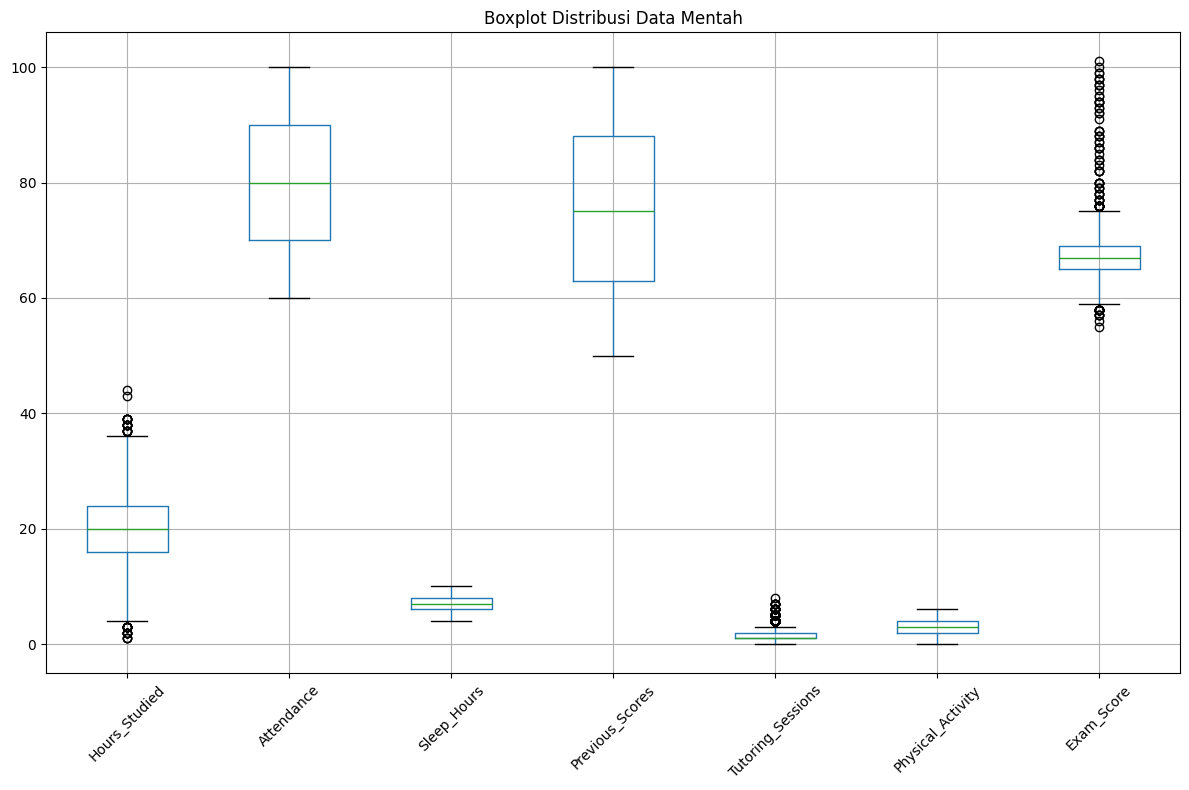

In [ ]:
# memilih kolom numerik
numerical_cols = df.select_dtypes(include='number').columns

# atur ukuran
plt.figure(figsize=(12, 8))

# boxplot vertikal untuk setiap kolom
df[numerical_cols].boxplot(figsize=(12, 8), rot=45)
plt.title('Boxplot Distribusi Data Mentah')
plt.tight_layout()
plt.show()

### **Analisis Outlier (Metode IQR)**

Berdasarkan deteksi menggunakan metode Interquartile Range (IQR), ditemukan outlier pada beberapa fitur numerik sebagai berikut:

- **Hours_Studied**: 43 outlier  
- **Tutoring_Sessions**: 430 outlier  
- **Exam_Score**: 104 outlier  
- Fitur lainnya tidak menunjukkan adanya outlier signifikan.

### **Temuan Awal**

- **Hours_Studied** memiliki outlier pada nilai yang sangat rendah (1–3 jam/minggu) dan sangat tinggi (37–44 jam/minggu). Meskipun tergolong ekstrem secara statistik, nilai-nilai ini masih mungkin terjadi dalam konteks nyata.

- **Tutoring_Sessions** memiliki jumlah outlier yang cukup besar, terutama pada nilai tinggi (7–8 sesi), jauh di atas rata-rata (1–2 sesi). Hal ini menunjukkan adanya distribusi yang tidak merata pada variabel ini.

- **Exam_Score** memiliki outlier pada nilai sangat tinggi (99–101) dan rendah (55–57). Nilai 101 sebelumnya telah diidentifikasi sebagai kemungkinan **data entry error**, sedangkan nilai rendah masih berada dalam batas yang mungkin terjadi.

### **Implikasi**

- Tidak semua outlier perlu dihapus, terutama jika masih masuk akal secara kontekstual.  
- Outlier pada **Hours_Studied** dan sebagian besar **Tutoring_Sessions** dapat dipertahankan, namun tetap perlu dipertimbangkan dalam analisis lanjutan.  
- Outlier pada **Exam_Score**, khususnya nilai di atas 100, perlu ditangani karena berpotensi merupakan kesalahan data.  
- Untuk menjaga stabilitas distribusi dan mengurangi pengaruh nilai ekstrem, dapat dipertimbangkan penggunaan teknik seperti *capping* pada tahap data cleaning.

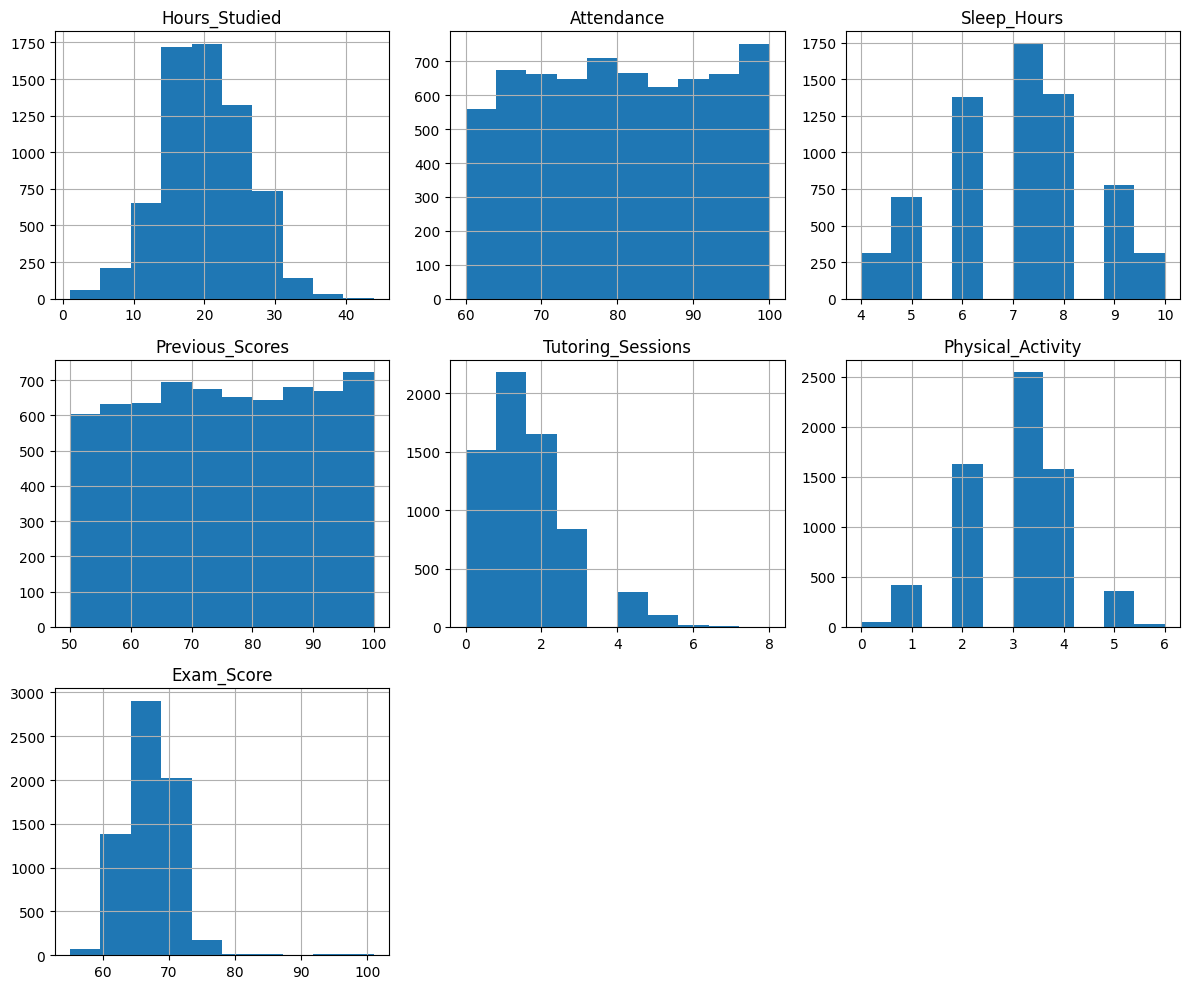

In [ ]:
# menampilkan grafik histogram (distribusi penyebaran data)
df.hist(figsize=(12, 10), layout=(3,3))
plt.tight_layout()
plt.show()

### **Ringkasan Data Assessing**

Berdasarkan hasil eksplorasi dan evaluasi kualitas data, diperoleh beberapa temuan utama sebagai berikut:

### **Struktur Dataset**
Dataset terdiri dari **6.607 baris** dan **20 kolom**, yang mencakup **7 fitur numerik** dan **13 fitur kategorikal**. Komposisi ini menunjukkan bahwa dataset memiliki variasi tipe data yang cukup untuk analisis lebih lanjut.

---

### **Permasalahan Data yang Ditemukan**

- **Missing Value**  
  Ditemukan nilai kosong pada 3 kolom kategorikal:
  - `Teacher_Quality` (78 data)
  - `Parental_Education_Level` (90 data)
  - `Distance_from_Home` (67 data)  
  Proporsinya relatif kecil (<2%), sehingga masih dapat ditangani dengan metode imputasi tanpa menghapus data.

- **Nilai Tidak Valid**  
  Terdapat nilai **Exam_Score = 101**, yang melebihi batas maksimum umum (100), sehingga diindikasikan sebagai kesalahan input.

- **Outlier**  
  Outlier terdeteksi pada:
  - `Hours_Studied` (43 data)
  - `Tutoring_Sessions` (430 data)
  - `Exam_Score` (104 data)  
  Sebagian besar outlier masih dalam batas logis, namun tetap perlu dikontrol untuk menjaga stabilitas distribusi.

---

### ✅ Validasi Data
- Tidak ditemukan **data duplikat**  
- Tidak terdapat **nilai negatif** pada seluruh fitur numerik  

Hal ini menunjukkan bahwa secara umum kualitas data cukup baik dan tidak memerlukan penanganan pada aspek tersebut.

---

### 🎯 Implikasi
Secara keseluruhan, dataset berada dalam kondisi yang cukup baik, dengan beberapa isu utama yang perlu ditangani pada tahap data cleaning, yaitu:
- Imputasi missing value  
- Perbaikan nilai tidak valid  
- Penanganan outlier  

Setelah proses tersebut dilakukan, dataset akan lebih siap untuk tahap merumuskan pertanyaan bisnis, Exploration Data Analysis (EDA) dan pemodelan.

## **🧹 Data Cleaning**
Pada tahap ini, setelah ditemukan deteksi *missing value* dan *outlier* pada proses *assesing*, data mentah dibersihkan dan dipersiapkan agar siap dianalisis. Proses mencakup penanganan nilai kosong (*missing values*) dan penanganan deteksi *outlier*.

In [ ]:
# mengganti nilai inaccurate data pada nilai max exam_score (asumsi kesalahan input)
df['Exam_Score'] = df['Exam_Score'].replace(df['Exam_Score'].max(), 100)

In [ ]:
# mengecek ulang inaccurate data pada nilai max exam_score
df[df.Exam_Score == df.Exam_Score.max()]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,100


### **Perbaikan Nilai Tidak Valid (Exam_Score)**

1. **Penggantian Nilai Maksimum (101 → 100)**  
Nilai maksimum pada kolom `Exam_Score` yang sebelumnya bernilai **101** (indeks 1525) telah diperbaiki menjadi **100**, sesuai dengan batas maksimum yang umum digunakan.

2. **Hasil Pengecekan Ulang Nilai Maksimum**  
Setelah dilakukan perbaikan, nilai maksimum pada kolom `Exam_Score` kini adalah **100**, dengan total **2 baris data** yang memiliki nilai tersebut.

### **Validasi Hasil Cleaning**
- Tidak ditemukan lagi nilai `Exam_Score` yang melebihi batas maksimum.
- Distribusi nilai pada kolom `Exam_Score` menjadi lebih konsisten dan sesuai dengan konteks data.

### **Implikasi**
- Perbaikan ini menghilangkan potensi **bias akibat nilai tidak valid** dalam analisis statistik maupun pemodelan.
- Dataset kini lebih representatif terhadap kondisi nyata, sehingga hasil analisis selanjutnya menjadi lebih dapat dipercaya.

In [ ]:
# menangani missing value dengan group based imputation dengan pertimbangan variabel school_type
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    if col == 'Teacher_Quality':
        df[col] = df.groupby('School_Type')[col].transform(
            lambda x: x.fillna(x.mode()[0] if not x.mode().empty else df[col].mode()[0])
        )
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# mengecek ulang nilai missing value
missing = df.isnull().sum().to_frame(name='Jumlah Missing Value')

display(missing)

if (missing['Jumlah Missing Value'] == 0).all():
    print("\n✅ Tidak ada missing value pada dataset.")
else:
    print("\n⚠️ Dataset masih memiliki missing value.")

,Jumlah Missing Value
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



✅ Tidak ada missing value pada dataset.


In [ ]:
# menghitung ulang persentase missing value per kolom
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Hours_Studied                 0.0
Attendance                    0.0
Parental_Involvement          0.0
Access_to_Resources           0.0
Extracurricular_Activities    0.0
Sleep_Hours                   0.0
Previous_Scores               0.0
Motivation_Level              0.0
Internet_Access               0.0
Tutoring_Sessions             0.0
Family_Income                 0.0
Teacher_Quality               0.0
School_Type                   0.0
Peer_Influence                0.0
Physical_Activity             0.0
Learning_Disabilities         0.0
Parental_Education_Level      0.0
Distance_from_Home            0.0
Gender                        0.0
Exam_Score                    0.0
dtype: float64


### **Penanganan Missing Value**
Missing value pada variabel `Teacher_Quality` ditangani menggunakan pendekatan berbasis kelompok (*group-based imputation*) dengan mempertimbangkan variabel `School_Type`. Pendekatan ini digunakan karena kualitas pengajaran cenderung dipengaruhi oleh jenis sekolah, sehingga imputasi berbasis kelompok dianggap lebih representatif.

Sementara itu, variabel kategorikal lainnya (`Parental_Education_Level` dan `Distance_from_Home`) ditangani menggunakan **modus global**, karena tidak ditemukan indikasi hubungan kuat dengan variabel lain.

### **Validasi Hasil Cleaning**
Berdasarkan hasil pengecekan ulang:

- Seluruh kolom dalam dataset memiliki **0 missing value**
- Persentase missing value pada setiap kolom adalah **0%**

Hal ini menunjukkan bahwa proses imputasi telah berhasil dilakukan secara menyeluruh tanpa menyisakan data yang hilang.

### **Implikasi**
- Dataset kini berada dalam kondisi **lengkap (complete data)** dan siap digunakan untuk analisis lanjutan.
- Tidak diperlukan penghapusan data, sehingga seluruh informasi tetap dipertahankan.
- Kualitas data meningkat dan lebih konsisten, yang dapat mendukung performa analisis maupun pemodelan yang lebih optimal.

In [ ]:
# menangani outlier: menggunakan metode capping
# nilai outlier diganti dengan batas bawah/atas sesuai dengan kolom yang memiliki outlier
outlier_cols = ['Hours_Studied', 'Tutoring_Sessions']

df_capped = df.copy()

for col in outlier_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    print(f"{col}: outlier di-capped ke rentang [{lower:.2f}, {upper:.2f}]")

Hours_Studied: outlier di-capped ke rentang [4.00, 36.00]
Tutoring_Sessions: outlier di-capped ke rentang [-0.50, 3.50]


In [ ]:
# mengecek ulang outlier gunakan df_capped (hasil capping)
print("Jumlah Outlier Setelah Penanganan dengan Metode Capping")
for col in outlier_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = df_capped[(df_capped[col] < lower) | (df_capped[col] > upper)].shape[0]
    print(f"{col}: {outliers_count} outliers")

Jumlah Outlier Setelah Penanganan dengan Metode Capping
Hours_Studied: 0 outliers
Tutoring_Sessions: 0 outliers


In [ ]:
# Menetapkan df_clean sebagai dataset yang akan digunakan untuk EDA dan Modeling
df_clean = df_capped.copy()

print("Dataset final 'df_clean' telah disiapkan.")
print(f"Jumlah baris: {df_clean.shape[0]}")
print(f"Fitur yang di-capping: Hours_Studied, Tutoring_Sessions")

Dataset final 'df_clean' telah disiapkan.
Jumlah baris: 6607
Fitur yang di-capping: Hours_Studied, Tutoring_Sessions


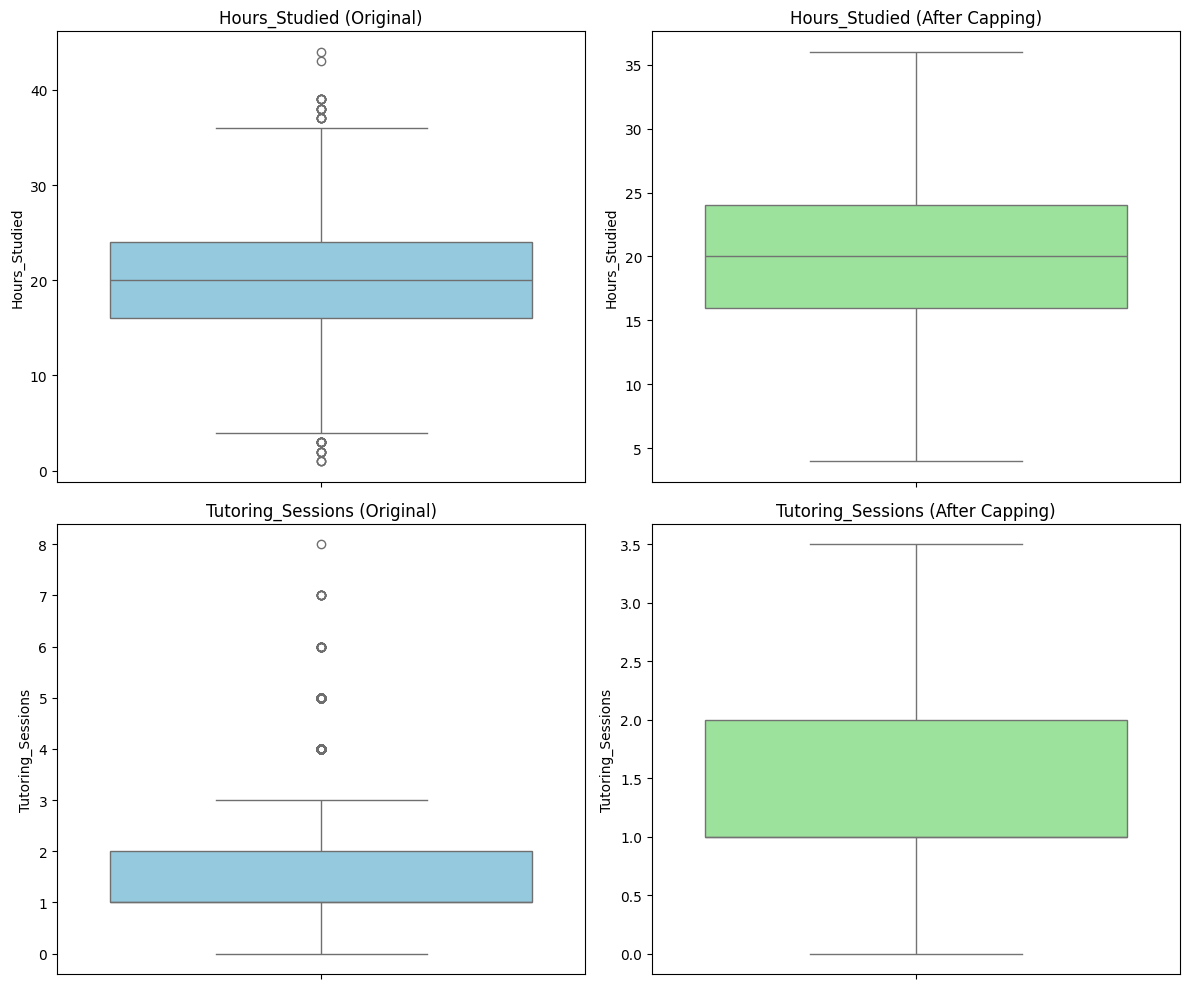

In [ ]:
# visualisasi perbandingan sebelum dan sesudah capping
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Hours_Studied - Original
sns.boxplot(y=df['Hours_Studied'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Hours_Studied (Original)')

# Hours_Studied - After Capping
sns.boxplot(y=df_clean['Hours_Studied'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Hours_Studied (After Capping)')

# Tutoring_Sessions - Original
sns.boxplot(y=df['Tutoring_Sessions'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Tutoring_Sessions (Original)')

# Tutoring_Sessions - After Capping
sns.boxplot(y=df_clean['Tutoring_Sessions'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Tutoring_Sessions (After Capping)')

plt.tight_layout()
plt.show()

In [ ]:
# membandingkan rentang nilai (min & max) untuk data yang mengandung outlier
comparison = pd.DataFrame({
    'Kolom': ['Hours_Studied', 'Tutoring_Sessions', 'Exam_Score'],
    'Min (Original)': [df['Hours_Studied'].min(), df['Tutoring_Sessions'].min(), df['Exam_Score'].min()],
    'Max (Original)': [df['Hours_Studied'].max(), df['Tutoring_Sessions'].max(), df['Exam_Score'].max()],
    'Min (Cleaned)': [df_clean['Hours_Studied'].min(), df_clean['Tutoring_Sessions'].min(), df_clean['Exam_Score'].min()],
    'Max (Cleaned)': [df_clean['Hours_Studied'].max(), df_clean['Tutoring_Sessions'].max(), df_clean['Exam_Score'].max()]
})

display(comparison)

,Kolom,Min (Original),Max (Original),Min (Cleaned),Max (Cleaned)
0,Hours_Studied,1,44,4.0,36.0
1,Tutoring_Sessions,0,8,0.0,3.5
2,Exam_Score,55,100,55.0,100.0


### **Penanganan Outlier (Metode Capping / Winsorizing)**

Outlier pada fitur numerik ditangani menggunakan metode **capping (Winsorizing)** berbasis batas Interquartile Range (IQR).

- `Hours_Studied` di-capping ke rentang **[4.00, 36.00]**
- `Tutoring_Sessions` di-capping ke rentang **[0.00, 3.50]**

> **Catatan:** Batas bawah `Tutoring_Sessions` dari perhitungan IQR menghasilkan nilai **-0.5**, namun tidak berdampak pada data karena nilai minimum aktual kolom ini adalah **0** — tidak ada baris yang terkena batas bawah tersebut. Nilai yang ditampilkan di atas (0.00) adalah batas efektif setelah dibulatkan ke nilai valid terendah.

Setelah dilakukan capping, hasil pengecekan menunjukkan bahwa:
- **Hours_Studied: 0 outlier**
- **Tutoring_Sessions: 0 outlier**

Hal ini menandakan bahwa nilai ekstrem telah berhasil dikendalikan tanpa menghapus data.

### **Validasi Hasil Cleaning**

Perbandingan sebelum dan sesudah capping menunjukkan:
- Nilai maksimum pada `Hours_Studied` berubah dari **44 → 36**
- Nilai maksimum pada `Tutoring_Sessions` berubah dari **8 → 3.5**
- Rentang nilai menjadi lebih terkontrol dan tidak lagi mengandung outlier ekstrem

Sementara itu:
- `Exam_Score` tetap berada pada rentang **55–100** dan **tidak dilakukan capping**

### **Pertimbangan Khusus (Exam_Score)**

Kolom `Exam_Score` tidak dilakukan capping karena berperan sebagai **variabel sumber label target** dalam analisis.

Melakukan capping pada kolom ini berpotensi:
- Menghilangkan variasi alami data
- Mengurangi representasi performa nyata siswa
- Merusak distribusi label `Risk_Category` yang diturunkan langsung dari kolom ini

Nilai ekstrem seperti skor rendah (55) atau tinggi (100) masih dianggap valid secara kontekstual, sehingga tetap dipertahankan. Satu-satunya nilai tidak valid (101) telah diperbaiki pada tahap sebelumnya.

### **Implikasi**

- Capping pada fitur input (`Hours_Studied`, `Tutoring_Sessions`) membantu mengurangi pengaruh nilai ekstrem terhadap distribusi data dan meningkatkan stabilitas model.
- Data tetap dipertahankan (tidak ada penghapusan baris), sehingga informasi tidak hilang.
- Variabel target (`Exam_Score`) tetap alami, sehingga hasil pemodelan lebih merepresentasikan kondisi sebenarnya.

Dengan demikian, dataset hasil cleaning (`df_clean`) telah berada dalam kondisi yang lebih stabil dan siap digunakan untuk tahap eksplorasi data (EDA) maupun pemodelan.

### **Kesimpulan Proses Data Cleaning**

Pada tahap data cleaning, dilakukan beberapa langkah untuk meningkatkan kualitas dan konsistensi dataset berdasarkan hasil data assessing sebelumnya.

### **Langkah yang Dilakukan**

- **Penanganan Missing Value**  
  Missing value pada 3 kolom kategorikal berhasil diatasi menggunakan kombinasi:
  - *Group-based imputation* pada `Teacher_Quality` berdasarkan `School_Type`
  - *Modus global* pada `Parental_Education_Level` dan `Distance_from_Home`  
  Setelah proses ini, seluruh kolom memiliki **0 missing value (0%)**.

- **Perbaikan Nilai Tidak Valid**  
  Nilai tidak wajar pada `Exam_Score` (101) telah diperbaiki menjadi 100, sehingga seluruh nilai berada dalam rentang yang valid.

- **Penanganan Outlier**  
  Outlier pada fitur numerik ditangani menggunakan metode **capping (Winsorizing)**:
  - `Hours_Studied` → [4.00, 36.00]  
  - `Tutoring_Sessions` → [0.00, 3.50]  
  Setelah capping, tidak ditemukan lagi outlier pada kedua fitur tersebut.

  Variabel `Exam_Score` tidak dilakukan capping karena berperan sebagai target, sehingga distribusinya tetap dipertahankan secara alami.

### **Hasil Akhir**

- Tidak terdapat **missing value**
- Tidak terdapat **nilai tidak valid**
- Outlier pada fitur utama telah dikendalikan
- Tidak ada **duplikasi** maupun **nilai negatif**

Dataset hasil cleaning (`df_clean`) memiliki kualitas yang lebih baik, lebih konsisten, dan siap digunakan untuk tahap **Exploratory Data Analysis (EDA)** maupun **pemodelan**.

## **🏗️ Pembuatan Kolom Target: Risk_Category (Checklist 7 — Feature Engineering)**

Tahap ini merupakan implementasi **Feature Engineering** melalui pendekatan ***Target Construction*** (konstruksi target), yaitu proses membuat kolom label baru yang diturunkan secara eksplisit dari kolom yang sudah ada berdasarkan aturan domain tertentu.

Pendekatan ini dipilih karena kolom `Risk_Category` tidak tersedia secara eksplisit dalam dataset mentah — informasi risiko akademik harus dikonstruksi dari `Exam_Score` menggunakan pengetahuan domain pendidikan. Proses ini mengubah data numerik mentah menjadi representasi kategoris yang lebih bermakna dan langsung dapat digunakan sebagai target klasifikasi oleh model *machine learning*.

In [ ]:
# membuat kolom target Risk_Category dari Exam_Score
# threshold berbasis domain: <60 = Tinggi, 60-70 = Sedang, >70 = Rendah
bins   = [0, 59, 70, 100]
labels = ['High', 'Medium', 'Low']

df_clean['Risk_Category'] = pd.cut(
    df_clean['Exam_Score'],
    bins=bins,
    labels=labels,
    right=True
)

print("Kolom Risk_Category berhasil dibuat.")
print(f"Tipe data: {df_clean['Risk_Category'].dtype}")
print(f"\nDistribusi kelas (jumlah):")
print(df_clean['Risk_Category'].value_counts().sort_index())
print(f"\nDistribusi kelas (persentase):")
print(df_clean['Risk_Category'].value_counts(normalize=True).mul(100).round(2).sort_index().astype(str) + '%')

Kolom Risk_Category berhasil dibuat.
Tipe data: category

Distribusi kelas (jumlah):
Risk_Category
High        68
Medium    5456
Low       1083
Name: count, dtype: int64

Distribusi kelas (persentase):
Risk_Category
High       1.03%
Medium    82.58%
Low       16.39%
Name: proportion, dtype: object


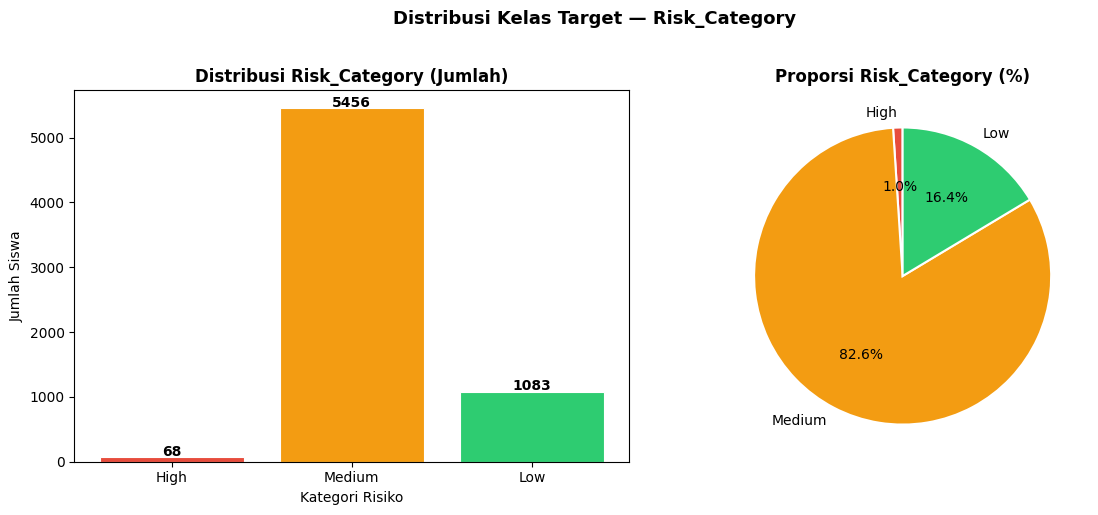

In [ ]:
# visualisasi distribusi Risk_Category
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart jumlah
counts = df_clean['Risk_Category'].value_counts().reindex(['High', 'Medium', 'Low'])
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribusi Risk_Category (Jumlah)', fontweight='bold')
axes[0].set_xlabel('Kategori Risiko')
axes[0].set_ylabel('Jumlah Siswa')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# pie chart persentase
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporsi Risk_Category (%)', fontweight='bold')

plt.suptitle('Distribusi Kelas Target — Risk_Category', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Pembentukan Variabel Target (Risk_Category)**

Kolom `Risk_Category` dibuat dari `Exam_Score` menggunakan threshold berbasis domain pendidikan Indonesia:

| Kategori | Rentang Exam_Score | Makna |
|---|---|---|
| **High** | < 60 | Di bawah ambang lulus — butuh intervensi segera |
| **Medium** | 60 – 70 | Lulus tapi di bawah rata-rata — perlu dipantau |
| **Low** | > 70 | Performa baik — tidak perlu intervensi khusus |

Threshold ini dipilih karena mencerminkan **KKM (Kriteria Ketuntasan Minimal)** yang umum digunakan di sekolah Indonesia (nilai 60 dan 70 sebagai batas kategori), sehingga label yang dihasilkan memiliki interpretasi yang langsung dapat dipahami oleh guru sebagai pengguna sistem EduPredict AI.

**Catatan untuk tim AI Engineer:**

Apabila hasil distribusi menunjukkan ketidakseimbangan kelas (salah satu kategori mendominasi lebih dari 60%), perlu diterapkan teknik penyeimbangan data seperti **SMOTE** pada tahap preprocessing sebelum training model.

In [ ]:
# ekspor dataset bersih beserta kolom Risk_Category ke format CSV
output_path = 'edupredict_cleaned_v1.csv'
df_clean.to_csv(output_path, index=False)

print(f"Dataset berhasil diekspor ke '{output_path}'")
print(f"Shape akhir : {df_clean.shape[0]} baris × {df_clean.shape[1]} kolom")
print(f"Kolom       : {list(df_clean.columns)}")

Dataset berhasil diekspor ke 'edupredict_cleaned_v1.csv'
Shape akhir : 6607 baris × 21 kolom
Kolom       : ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Risk_Category']


In [ ]:
# melihat 5 data pertama dari dataset clean
df_clean.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Risk_Category
0,23,84,Low,High,No,7,73,Low,Yes,0.0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Medium
1,19,64,Low,Medium,No,8,59,Low,Yes,2.0,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Medium
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2.0,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Low
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1.0,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Low
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3.0,...,High,Public,Neutral,4,No,College,Near,Female,70,Medium


### **Ekspor Dataset Final V1**

Dataset `df_clean` telah diekspor ke file `edupredict_cleaned_v1.csv` dan siap diserahkan kepada tim AI Engineer untuk proses training awal. Dataset ini mencakup 21 kolom (20 fitur asli + 1 kolom target `Risk_Category`) dengan 6.607 baris data yang telah melewati seluruh proses wrangling.

File ini merupakan sumber data tunggal (*single source of truth*) yang akan digunakan oleh seluruh learning path — tim AI Engineer untuk training model, tim Data Science untuk EDA lanjutan, dan tim Full-Stack untuk referensi struktur data pada database.

# **❓Pertanyaan Bisnis Terukur (Checklist 3)**

Pada tahap ini, mendefinisikan pertanyaan bisnis yang dapat diukur berarti merumuskan pertanyaan spesifik yang jawabannya bisa dinyatakan dalam bentuk angka atau metrik berdasarkan data yang tersedia. Tujuannya agar analisis data terarah, hasilnya objektif, dan keberhasilan proyek dapat dievaluasi secara jelas.

## **🎯 Business Questions Based on Dataset**

Analisis ini dirancang untuk menjawab beberapa pertanyaan kunci terkait faktor-faktor
yang memengaruhi performa akademik siswa dalam konteks sistem *Early Warning*
(EduPredict AI). Setiap pertanyaan disusun menggunakan kerangka **SMART**
(*Specific, Measurable, Achievable, Relevant, Time-bound*) agar analisis terarah,
hasilnya objektif, dan keberhasilan proyek dapat dievaluasi secara jelas.

---

#### **BQ1 — Faktor Perilaku Belajar**

> Faktor perilaku belajar mana yang memiliki korelasi paling kuat terhadap nilai
> ujian siswa (*Exam Score*)?

| Kriteria | Keterangan |
|---|---|
| **Specific** | Menganalisis korelasi antara `Hours_Studied`, `Attendance`, `Sleep_Hours`, `Tutoring_Sessions`, dan `Physical_Activity` terhadap `Exam_Score` |
| **Measurable** | Nilai korelasi Pearson (−1 sampai +1) untuk setiap fitur, diurutkan dari yang terkuat ke terlemah. Faktor dengan korelasi ≥ 0.4 dikategorikan sebagai sinyal kuat |
| **Achievable** | Semua kolom tersedia di dataset tanpa missing value |
| **Relevant** | Menentukan faktor mana yang paling perlu dipantau guru sebagai *early warning signal* — menjawab RQ1 project plan |
| **Time-bound** | Berdasarkan data snapshot 6.607 siswa di dataset ini |

---

#### **BQ2 — Peran Keterlibatan Orang Tua**

> Berapa rata-rata nilai ujian siswa berdasarkan tingkat keterlibatan orang tua
> (*Parental Involvement*), dan apakah terdapat perbedaan yang signifikan antar
> kelompok?

| Kriteria | Keterangan |
|---|---|
| **Specific** | Membandingkan rata-rata `Exam_Score` pada kelompok `Parental_Involvement` = Low, Medium, dan High |
| **Measurable** | Rata-rata `Exam_Score` per kelompok (skala 0–100) dan selisih rata-rata antar kelompok. Jika selisih ≥ 5 poin antar kelompok, keterlibatan orang tua dikonfirmasi sebagai faktor protektif |
| **Achievable** | Kolom `Parental_Involvement` dan `Exam_Score` tersedia lengkap tanpa missing value |
| **Relevant** | Membuktikan apakah keterlibatan orang tua berdampak nyata pada performa akademik — dasar rekomendasi intervensi yang melibatkan keluarga |
| **Time-bound** | Berdasarkan data 6.607 siswa di dataset ini |

---

#### **BQ3 — Motivasi dan Perilaku Belajar**

> Berapa rata-rata jam belajar (*Hours Studied*) dan tingkat kehadiran (*Attendance*)
> berdasarkan level motivasi siswa (*Motivation Level*), serta seberapa besar
> perbedaannya?

| Kriteria | Keterangan |
|---|---|
| **Specific** | Menghitung rata-rata `Hours_Studied` dan `Attendance` pada kelompok `Motivation_Level` = Low, Medium, High |
| **Measurable** | Rata-rata `Hours_Studied` (jam/minggu) dan rata-rata `Attendance` (%) per kelompok motivasi, serta selisih antara kelompok Low dan High. Jika rata-rata jam belajar kelompok Low ≤ 50% dari kelompok High, motivasi dikonfirmasi sebagai akar masalah |
| **Achievable** | Ketiga kolom tersedia lengkap tanpa missing value |
| **Relevant** | Menentukan apakah intervensi perlu menyasar motivasi terlebih dahulu sebelum aspek akademik lainnya |
| **Time-bound** | Berdasarkan data 6.607 siswa di dataset ini |

---

#### **BQ4 — Faktor Sosial-Ekonomi**

> Berapa persentase siswa dengan risiko akademik tinggi (*High Risk*) yang berasal
> dari keluarga berpendapatan rendah (*Low Family Income*) dan tidak memiliki akses
> internet (*No Internet Access*), dibandingkan dengan siswa dalam kondisi sebaliknya?

| Kriteria | Keterangan |
|---|---|
| **Specific** | Menganalisis proporsi `Family_Income = Low` dan `Internet_Access = No` pada kelompok siswa `Risk_Category = High` untuk mengidentifikasi faktor sosial-ekonomi mana yang paling dominan pada siswa berisiko tinggi |
| **Measurable** | Persentase siswa `Family_Income = Low` dan `Internet_Access = No` dalam kelompok `Risk_Category = High`. Jika salah satu faktor muncul pada lebih dari 50% siswa High Risk, faktor tersebut dikonfirmasi sebagai karakteristik dominan pada kelompok berisiko tinggi |
| **Achievable** | Semua kolom tersedia tanpa missing value |
| **Relevant** | Dasar rekomendasi program bantuan perangkat atau subsidi internet kepada pihak sekolah |
| **Time-bound** | Berdasarkan data 6.607 siswa di dataset ini |

---

#### **BQ5 — Kualitas Guru**

> Berapa rata-rata nilai ujian siswa berdasarkan kualitas guru (*Teacher Quality*),
> dan apakah kualitas guru yang rendah berkorelasi dengan proporsi siswa berisiko
> tinggi yang lebih besar?

| Kriteria | Keterangan |
|---|---|
| **Specific** | Menghitung rata-rata `Exam_Score` dan persentase `Risk_Category = High` pada kelompok `Teacher_Quality` = Low, Medium, High |
| **Measurable** | Rata-rata `Exam_Score` per kelompok (skala 0–100) dan persentase siswa High Risk per kelompok kualitas guru. Jika rata-rata Exam_Score kelompok Low lebih rendah ≥ 5 poin dari kelompok High, kualitas guru dikonfirmasi sebagai faktor sistemik |
| **Achievable** | Kolom `Teacher_Quality` tersedia setelah imputasi, tidak ada missing value |
| **Relevant** | Insight ini berguna untuk rekomendasi ke level manajemen sekolah, bukan hanya guru kelas |
| **Time-bound** | Berdasarkan data 6.607 siswa di dataset ini |

---

#### **BQ6 — Profil Siswa Berisiko Tinggi**

> Kombinasi kondisi seperti apa yang paling sering ditemukan pada siswa dengan
> risiko akademik tinggi (*High Risk*)?

| Kriteria | Keterangan |
|---|---|
| **Specific** | Mengidentifikasi distribusi `Motivation_Level`, `Internet_Access`, `Family_Income`, `Parental_Involvement`, dan `Teacher_Quality` yang dominan pada 68 siswa `Risk_Category = High` |
| **Measurable** | Persentase kemunculan setiap kondisi di dalam kelompok High Risk dibandingkan rata-rata keseluruhan dataset. Kombinasi yang muncul pada ≥ 30% siswa High Risk dikategorikan sebagai pola dominan |
| **Achievable** | Semua kolom tersedia; kelompok High Risk memiliki 68 baris yang cukup untuk analisis distribusi |
| **Relevant** | Menghasilkan "profil siswa paling berisiko" yang menjadi dasar narasi utama fitur Insight AI di dashboard Streamlit |
| **Time-bound** | Berdasarkan 68 siswa High Risk dari total 6.607 siswa di dataset ini |

# 📊 **Exploratory & Explanatory Data Analysis (Checklist 4 & 5)**

## **Project Overview**
EduPredict AI merupakan sistem Early Warning berbasis data yang dirancang untuk membantu mendeteksi risiko akademik siswa secara lebih dini.

Analisis ini bertujuan untuk:
- memahami pola performa akademik siswa,
- mengidentifikasi faktor-faktor yang berkaitan dengan Exam Score,
- serta menghasilkan insight yang dapat digunakan untuk dashboard monitoring, rekomendasi intervensi, dan pengembangan model machine learning.

## **Fokus Analisis**
Analisis dibagi menjadi dua pendekatan utama:
1. Exploratory Data Analysis (EDA)
2. Explanatory Analysis berbasis Business Questions

Dataset yang digunakan telah melalui proses cleaning dan data wrangling sebelumnya.

## **🎨 Set Up Visualisasi (Blueprint)**

In [ ]:
# Load data
df = pd.read_csv('edupredict_cleaned_v1.csv')

# =========================
# GLOBAL STYLE SETTING
# =========================

# Theme
sns.set_theme(style="whitegrid")

# Figure size default
plt.rcParams['figure.figsize'] = (8, 5)

# Font size
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

In [ ]:
# =========================
# COLOR PALETTE
# =========================

# Primary palette (umum)
main_palette = sns.color_palette("Blues", 6)

# Categorical palette
cat_palette = sns.color_palette("Set2")

# Risk category (IMPORTANT)
risk_palette = {
    'Low': '#2ECC71',     # hijau
    'Medium': '#F1C40F',  # kuning
    'High': '#E74C3C'     # merah
}

In [ ]:
def add_title_labels(title, xlabel=None, ylabel=None):
    plt.title(title, weight='bold')
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)

In [ ]:
# fungsi memunculkan angka untuk kategorikal
def barplot_with_values(data, x_col, y_col, ax):
    order = data.groupby(x_col)[y_col].mean().sort_values().index

    sns.barplot(
        data=data,
        x=x_col,
        y=y_col,
        order=order,
        palette=cat_palette,
        hue=x_col, # Assign x_col to hue to remove FutureWarning
        legend=False, # Suppress legend if hue is used
        ax=ax
    )

    # Tambahkan angka
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_title(f'{y_col} vs {x_col}', weight='bold')
    ax.tick_params(axis='x', rotation=20)

## **🔍 Exploratory Data Analysis (EDA) (Checklist 4)**

Tahap exploratory dilakukan untuk memahami karakteristik dasar dataset sebelum masuk ke analisis yang lebih spesifik.

Fokus utama pada tahap ini:
- Distribusi variabel numerik
- Keseimbangan data kategorikal
- Hubungan antar variabel

Insight dari tahap ini akan menjadi dasar dalam menjawab business questions pada tahap explanatory.

In [ ]:
# statistik deskriptif
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Risk_Category
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,...,6607,6607,6607,6607.000000,6607,6607,6607,6607,6607.000000,6607
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,...,3,2,3,NaN,2,3,3,2,NaN,3
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,...,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN,Medium
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,...,4003,4598,2638,NaN,5912,3313,3951,3814,NaN,5456
mean,19.971848,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.436355,...,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235508,NaN
std,5.951016,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.096018,...,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.889161,NaN
min,4.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000,NaN
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,...,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000,NaN
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,...,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000,NaN
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,...,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000,NaN


In [ ]:
# informasi dataset
df.info()

print()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   object 
 3   Access_to_Resources         6607 non-null   object 
 4   Extracurricular_Activities  6607 non-null   object 
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   object 
 8   Internet_Access             6607 non-null   object 
 9   Tutoring_Sessions           6607 non-null   float64
 10  Family_Income               6607 non-null   object 
 11  Teacher_Quality             6607 non-null   object 
 12  School_Type                 6607 non-null   object 
 13  Peer_Influence              6607 

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Risk_Category
0,23,84,Low,High,No,7,73,Low,Yes,0.0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Medium
1,19,64,Low,Medium,No,8,59,Low,Yes,2.0,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Medium
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2.0,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Low
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1.0,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Low
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3.0,...,High,Public,Neutral,4,No,College,Near,Female,70,Medium


- Dataset terdiri dari beberapa variabel numerik seperti Hours_Studied, Attendance, dan Exam_Score.
- Variabel kategorikal mencakup Motivation_Level, Parental_Involvement, dan Internet_Access.
- Tidak ditemukan missing value (asumsi setelah cleaning).
- Dataset siap digunakan untuk analisis lebih lanjut.

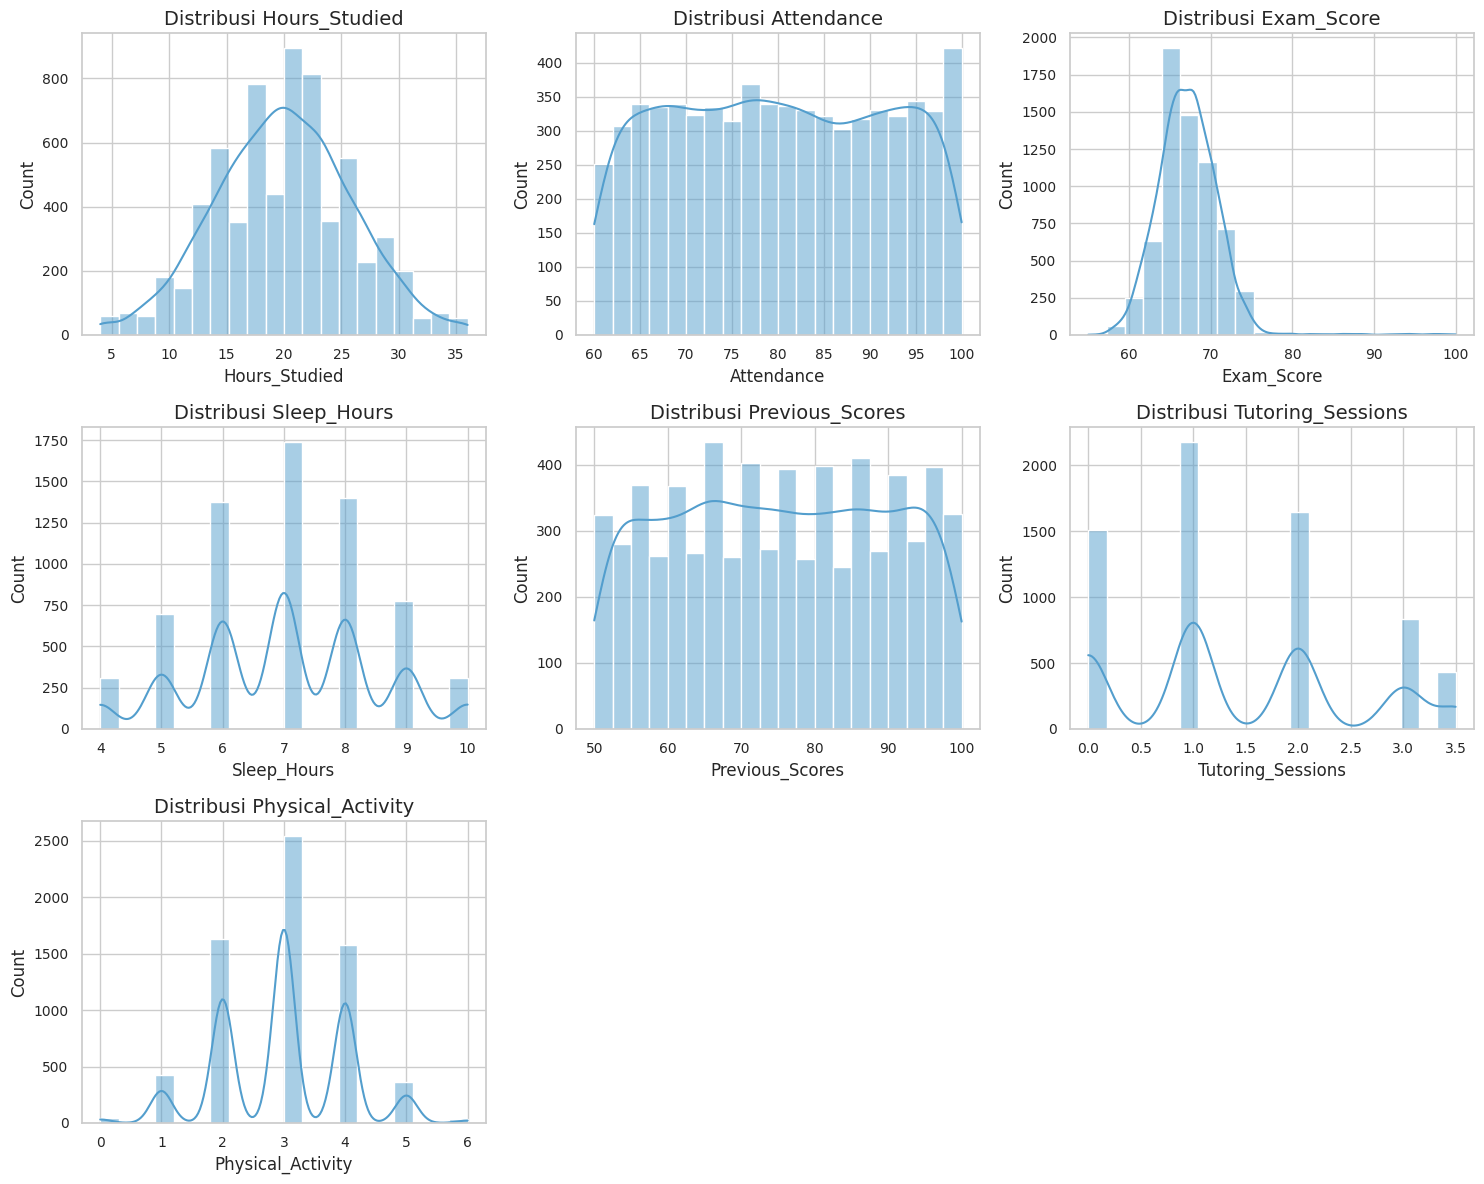

In [ ]:
# distribusi numerik (histogram)
num_cols = [
    'Hours_Studied', 'Attendance', 'Exam_Score',
    'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12)) # Changed from 2,3 to 3,3 to accommodate all columns
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=20, kde=True, color=main_palette[3], ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')

# Remove any unused subplots if there are fewer columns than subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insight Distribusi Variabel Numerik**

- **Hours_Studied** menunjukkan distribusi yang mendekati normal dengan konsentrasi utama di sekitar nilai tengah (sekitar 18–24 jam). Distribusi terlihat cukup seimbang meskipun terdapat sedikit kecenderungan *right skew*, yang mengindikasikan sebagian kecil siswa memiliki jam belajar lebih tinggi dibanding mayoritas.

- **Attendance** menunjukkan distribusi yang relatif merata pada rentang tinggi (60–100%). Tidak terlihat puncak yang terlalu dominan, yang mengindikasikan bahwa tingkat kehadiran siswa cenderung stabil dan tersebar cukup baik di seluruh rentang nilai tinggi.

- **Exam_Score** memiliki distribusi yang mendekati normal dengan konsentrasi utama pada rentang nilai sekitar 60–75. Terlihat sedikit *right tail* yang menunjukkan adanya sebagian kecil siswa dengan nilai ujian sangat tinggi dibanding mayoritas siswa lainnya.

- **Sleep_Hours** menunjukkan pola distribusi diskrit dengan lonjakan frekuensi pada angka tertentu, terutama di sekitar 6–8 jam. Pola ini mengindikasikan bahwa data jam tidur dicatat dalam bentuk bilangan bulat sehingga tidak membentuk distribusi kontinu.

- **Previous_Scores** memiliki distribusi yang relatif merata di seluruh rentang nilai tanpa puncak dominan. Hal ini menunjukkan bahwa performa akademik sebelumnya cukup beragam dan tidak terkonsentrasi pada kelompok nilai tertentu.

- **Tutoring_Sessions** menunjukkan distribusi diskrit dengan frekuensi utama pada jumlah sesi tertentu, terutama pada 1–2 sesi. Pola ini mengindikasikan bahwa sebagian besar siswa mengikuti jumlah bimbingan belajar dalam kategori terbatas, bukan dalam rentang kontinu.

- **Physical_Activity** juga menunjukkan pola distribusi diskrit dengan konsentrasi terbesar pada tingkat aktivitas sedang (sekitar 2–4). Distribusi ini mengindikasikan bahwa mayoritas siswa memiliki tingkat aktivitas fisik yang relatif moderat, sementara kategori aktivitas sangat rendah maupun sangat tinggi memiliki jumlah yang lebih sedikit.

**Implikasi:**

- Tidak seluruh variabel numerik mengikuti distribusi normal, sehingga asumsi normalitas tidak dapat diterapkan secara otomatis pada semua fitur.
- Variabel seperti **Sleep_Hours**, **Tutoring_Sessions**, dan **Physical_Activity** lebih tepat diperlakukan sebagai data diskrit karena memiliki pola berbasis kategori angka tertentu.
- Distribusi yang relatif merata pada variabel seperti **Attendance** dan **Previous_Scores** menunjukkan bahwa dataset memiliki variasi data yang cukup baik dan tidak terlalu terkonsentrasi pada satu kelompok nilai tertentu.

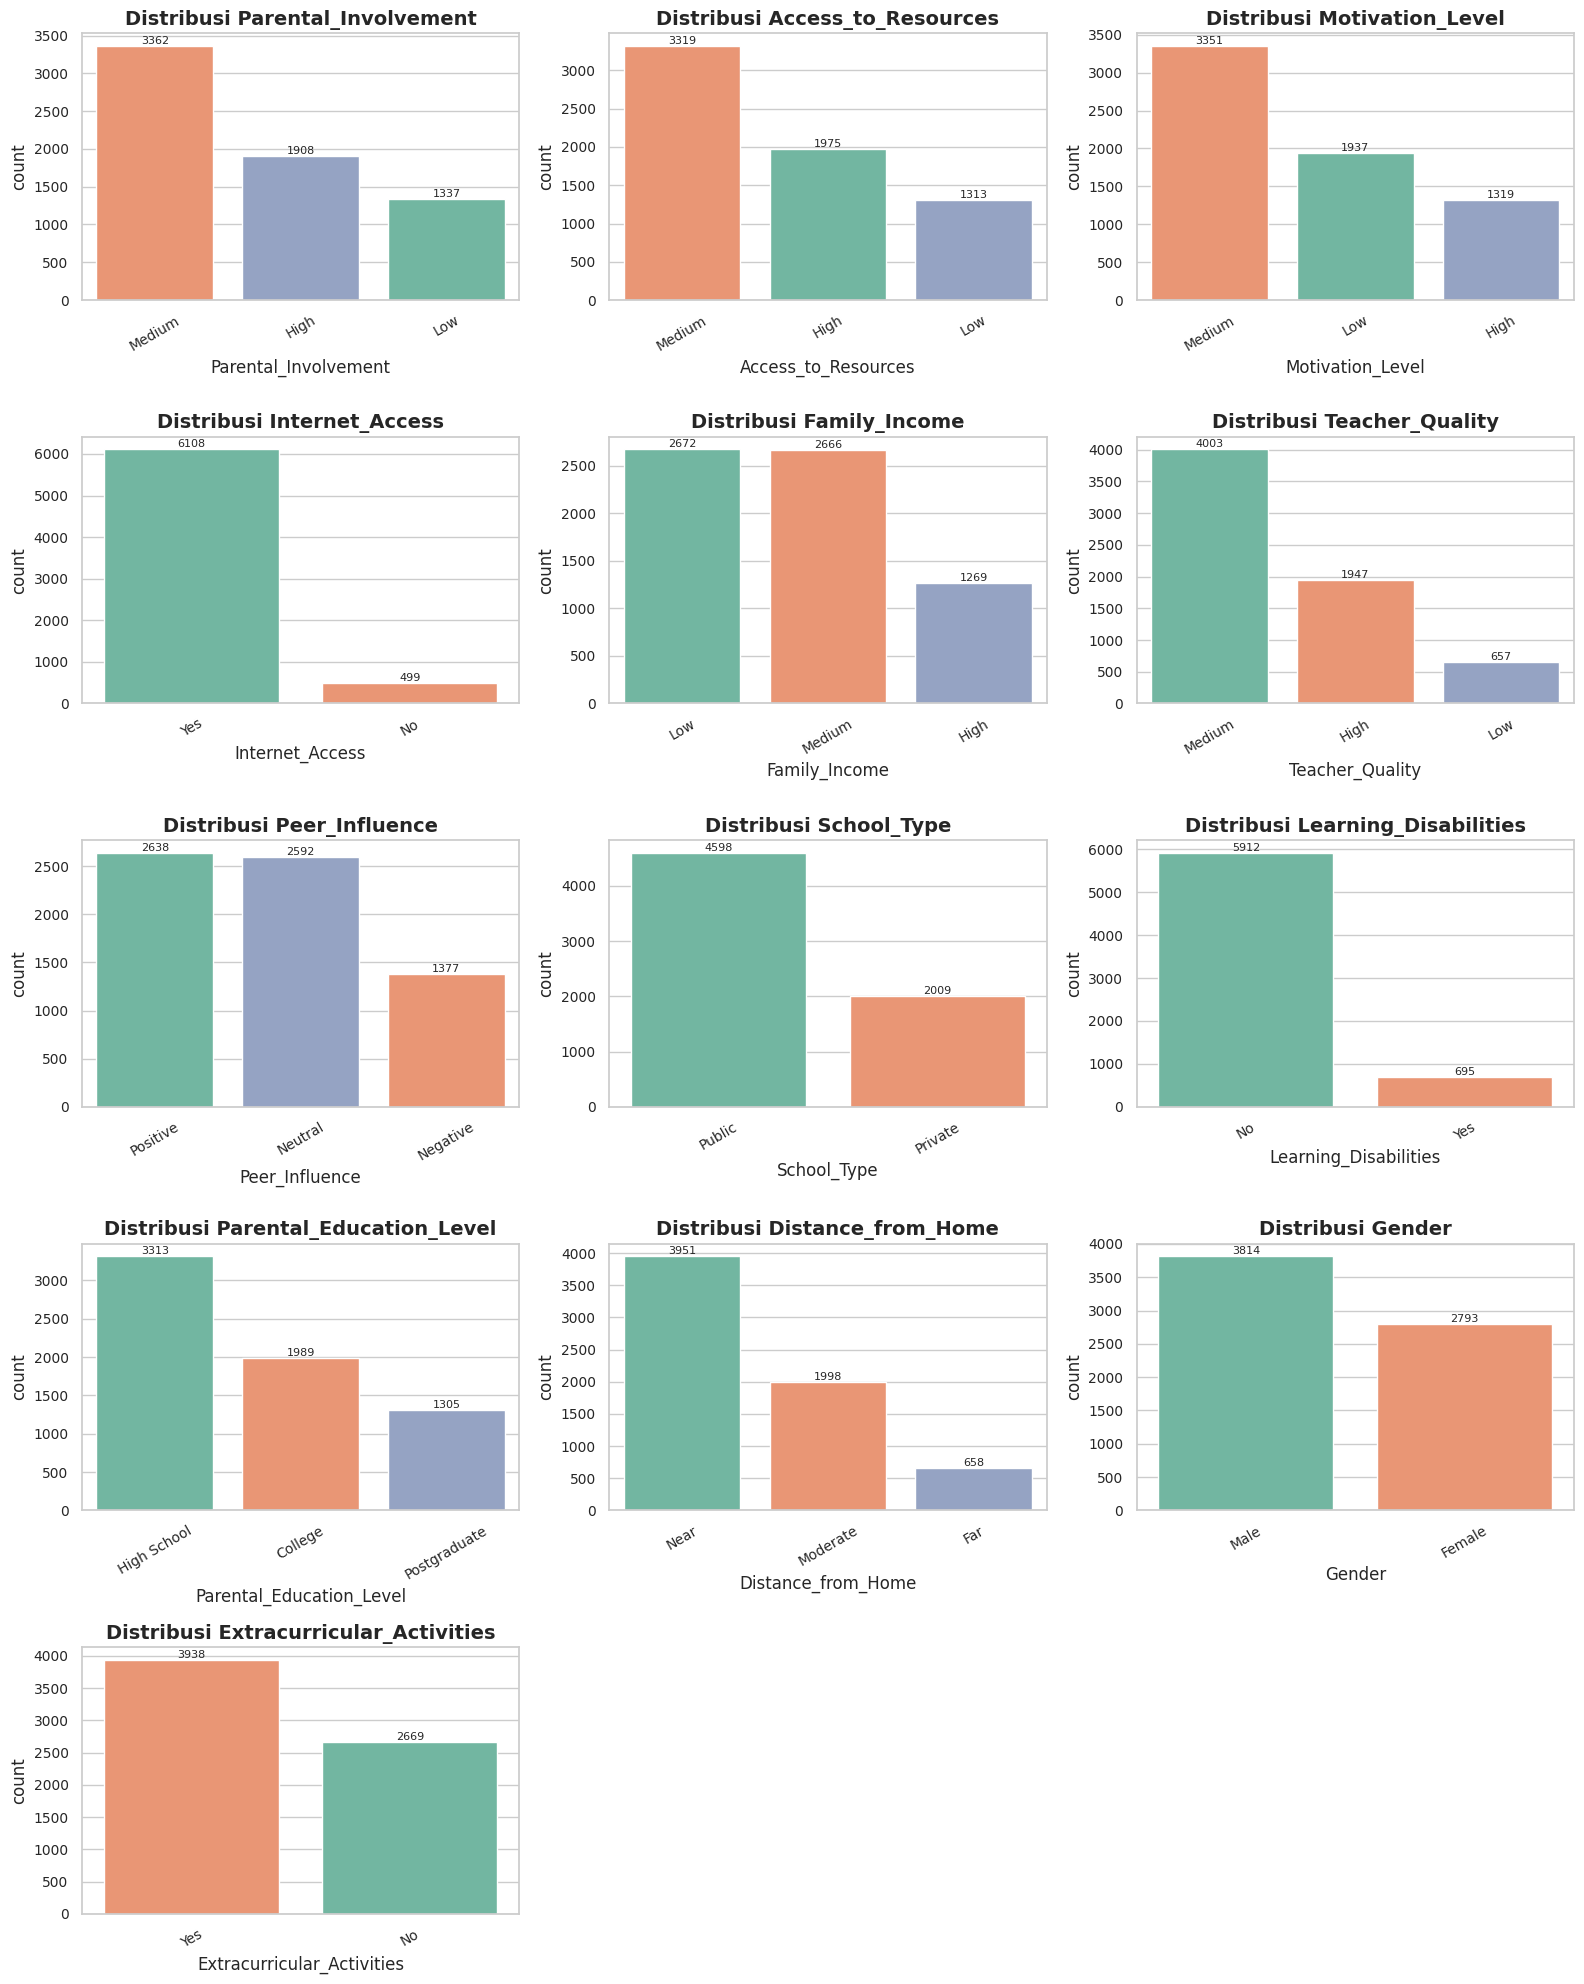

In [ ]:
cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
            'Internet_Access', 'Family_Income', 'Teacher_Quality',
            'Peer_Influence', 'School_Type', 'Learning_Disabilities',
            'Parental_Education_Level', 'Distance_from_Home', 'Gender',
            'Extracurricular_Activities']

fig, axes = plt.subplots(5, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2',
                  order=df[col].value_counts().index, hue=col, legend=False)
    axes[i].set_title(f'Distribusi {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f'{int(p.get_height())}',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=8)

# hapus subplot kosong
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Visualisasi distribusi 13 fitur kategorikal mengungkap beberapa pola dominan yang perlu diperhatikan dalam analisis lanjutan:

**Fitur dengan distribusi tidak seimbang (dominasi satu kategori):**
- **Internet_Access**: 92.5% siswa (6.108 dari 6.607) memiliki akses internet, sehingga kategori *No* sangat minoritas (499 siswa). Variabel ini berpotensi tidak informatif sebagai fitur pembeda karena variasi yang sangat rendah.
- **Learning_Disabilities**: 89.5% siswa tidak memiliki disabilitas belajar (5.912 siswa), sehingga distribusinya sangat tidak seimbang dan kemungkinan pengaruhnya terhadap model terbatas.
- **School_Type**: Didominasi sekolah negeri (*Public*) sebesar 69.6% (4.598 siswa) dibanding swasta (2.009 siswa).

**Fitur dengan distribusi relatif merata:**
- **Family_Income**: Distribusi *Low* (2.672) dan *Medium* (2.666) hampir identik, dengan *High* (1.269) lebih rendah — pola yang mewakili kondisi sosial-ekonomi yang beragam.
- **Gender**: Cukup seimbang antara laki-laki (3.814) dan perempuan (2.793), meskipun tidak sempurna 50:50.
- **Peer_Influence**: Terbagi relatif merata antara *Positive* (2.638) dan *Neutral* (2.592), dengan *Negative* (1.377) lebih rendah.

**Fitur dengan pola bertingkat konsisten:**
- **Parental_Involvement**, **Access_to_Resources**, **Motivation_Level**, dan **Teacher_Quality** semuanya menunjukkan pola serupa: kategori *Medium* paling dominan, diikuti *High*, kemudian *Low*. Pola ini mengindikasikan bahwa kondisi belajar sebagian besar siswa berada pada level menengah, bukan ekstrem.
- **Parental_Education_Level**: Didominasi *High School* (3.313), diikuti *College* (1.989) dan *Postgraduate* (1.305) — mencerminkan latar belakang pendidikan orang tua yang variatif.
- **Distance_from_Home**: Mayoritas tinggal dekat sekolah (*Near* 3.951), dengan sebagian kecil yang jauh (*Far* 658).

**Implikasi untuk pemodelan:**

Fitur dengan dominasi ekstrem seperti `Internet_Access` dan `Learning_Disabilities` perlu diperhatikan saat evaluasi kontribusi fitur — distribusi yang sangat tidak seimbang dapat membatasi kemampuan model membedakan pengaruh keduanya. Fitur-fitur dengan distribusi *Medium*-dominan menunjukkan bahwa dataset ini merepresentasikan populasi siswa yang umumnya berada pada kondisi moderat, konsisten dengan distribusi `Exam_Score` yang terkonsentrasi di 60–70.

## **Analisis Korelasi Antar Variabel Numerik**

Analisis korelasi digunakan untuk mengidentifikasi hubungan linear antar variabel numerik dalam dataset, khususnya untuk melihat faktor-faktor yang berhubungan dengan *Exam Score*.

Visualisasi dilakukan menggunakan heatmap untuk memberikan gambaran menyeluruh terhadap kekuatan hubungan antar variabel.

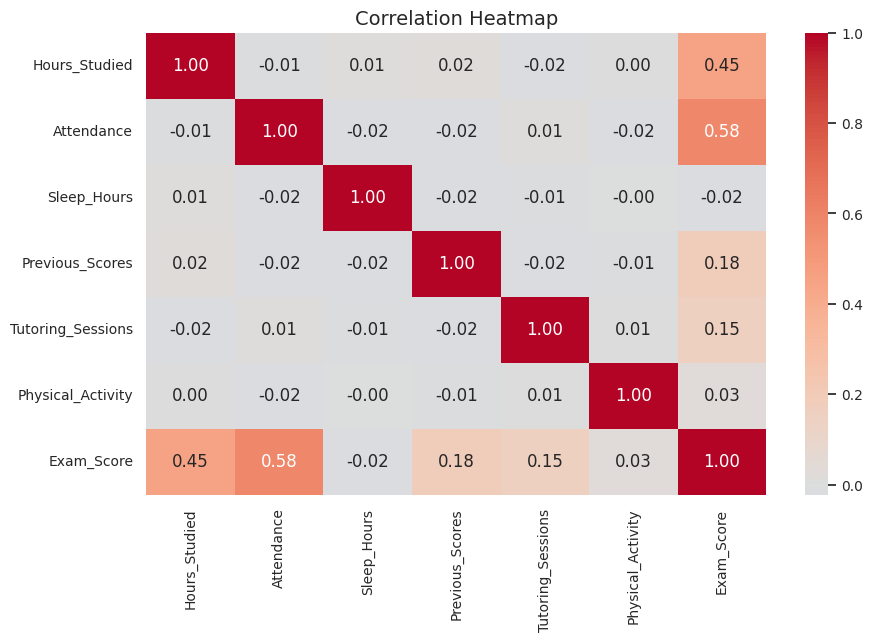

In [ ]:
# heatmap korelasi
plt.figure(figsize=(10,6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f"
)

plt.title('Correlation Heatmap')
plt.show()

- **Attendance** memiliki korelasi tertinggi terhadap *Exam Score* (≈ 0.58), menunjukkan bahwa kehadiran merupakan faktor yang paling kuat berhubungan dengan performa akademik siswa.

- **Hours_Studied** juga menunjukkan korelasi yang cukup kuat (≈ 0.45), mengindikasikan bahwa semakin banyak waktu belajar, semakin tinggi kecenderungan nilai siswa.

- **Previous_Scores** memiliki korelasi positif yang lebih rendah (≈ 0.18), yang menunjukkan adanya konsistensi performa, namun tidak menjadi faktor dominan.

- **Tutoring_Sessions** memiliki korelasi yang lemah (≈ 0.15), yang dapat mengindikasikan bahwa jumlah sesi bimbingan tidak secara langsung menentukan peningkatan nilai.

- **Sleep_Hours** dan **Physical_Activity** hampir tidak memiliki korelasi dengan *Exam Score*, menunjukkan bahwa pengaruhnya terhadap nilai tidak signifikan secara langsung.

- Korelasi antar variabel independen (misalnya antara Hours_Studied dan Attendance) sangat rendah (mendekati 0), yang menunjukkan tidak adanya multikolinearitas kuat dalam dataset.

**Kesimpulan:**
Faktor yang paling berpengaruh terhadap nilai ujian siswa adalah **kehadiran dan jam belajar**, sementara variabel lainnya memiliki pengaruh yang lebih kecil atau tidak langsung.

## **Kesimpulan Exploratory Analysis**

**Fitur Numerik:**
- **Hours_Studied** dan **Attendance** memiliki distribusi yang cukup menyebar dan tidak bias ekstrem, serta menunjukkan korelasi tertinggi terhadap *Exam Score* (masing-masing 0.45 dan 0.58). Keduanya menjadi kandidat fitur paling informatif dalam pemodelan.
- **Previous_Scores** memiliki distribusi yang relatif merata (hampir *uniform*), namun korelasinya rendah (0.18), sehingga bukan indikator kuat untuk performa saat ini.
- **Sleep_Hours** dan **Tutoring_Sessions** menunjukkan pola distribusi diskrit dan memiliki korelasi sangat rendah terhadap *Exam Score*, sehingga pengaruhnya kemungkinan bersifat tidak linear atau dimediasi faktor lain.

**Fitur Kategorikal:**
- Sebagian besar fitur kategorikal (Parental_Involvement, Access_to_Resources, Motivation_Level, Teacher_Quality) didominasi kategori *Medium*, konsisten dengan konsentrasi nilai ujian di rentang 60–70.
- **Internet_Access** dan **Learning_Disabilities** memiliki distribusi yang sangat tidak seimbang (>89% pada satu kategori), sehingga kontribusinya sebagai fitur pembeda perlu dievaluasi lebih lanjut.
- **Family_Income** dan **Gender** menunjukkan distribusi yang cukup merata, menjadikannya kandidat fitur yang representatif.

**Kesimpulan:**

Performa akademik siswa terutama berkorelasi dengan **konsistensi kehadiran** dan **intensitas belajar**. Distribusi fitur kategorikal yang cenderung *Medium*-dominan mencerminkan karakteristik dataset yang merepresentasikan populasi siswa pada kondisi moderat, bukan ekstrem pola yang perlu dipertimbangkan dalam interpretasi hasil pemodelan.

**Implikasi:**

Analisis lanjutan difokuskan pada **Attendance** dan **Hours_Studied** sebagai sinyal utama, dengan fitur kategorikal berperan sebagai konteks pendukung. Fitur dengan distribusi ekstrem tidak seimbang (`Internet_Access`, `Learning_Disabilities`) perlu diperhatikan dalam evaluasi *feature importance* model.

## **📖 Explanatory Analysis (Checklist 5)**

Setelah memahami karakteristik umum dataset melalui exploratory analysis, tahap berikutnya berfokus pada analisis yang lebih terarah untuk menjawab business questions utama dalam proyek EduPredict AI.

Analisis ini bertujuan mengidentifikasi faktor-faktor yang berkaitan dengan performa akademik dan risiko siswa secara lebih interpretatif.

## **🎯 BQ1 — Analisis Korelasi Faktor Perilaku Belajar**

Analisis ini bertujuan untuk mengidentifikasi faktor perilaku belajar yang memiliki hubungan paling kuat dengan nilai ujian siswa (*Exam Score*).

Pendekatan yang digunakan:

* Menghitung korelasi antar variabel numerik
* Memfokuskan analisis pada hubungan antara variabel perilaku belajar dan *Exam Score*
* Menyusun peringkat kekuatan korelasi untuk menentukan faktor paling dominan

Hasil dari analisis ini akan digunakan sebagai dasar dalam:

* Menentukan fitur penting dalam model prediksi
* Memberikan rekomendasi intervensi berbasis data


In [ ]:
# kolom numerik
num_cols = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity',
    'Exam_Score'
]

corr = df[num_cols].corr()

# korelasi terhadap Exam_Score
corr_target = corr['Exam_Score'].drop('Exam_Score')

# urutkan dari terbesar
corr_sorted = corr_target.sort_values(ascending=False)

corr_sorted

,Exam_Score
Attendance,0.581205
Hours_Studied,0.445489
Previous_Scores,0.175089
Tutoring_Sessions,0.150718
Physical_Activity,0.027832
Sleep_Hours,-0.017000


/tmp/ipykernel_244/2275909922.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


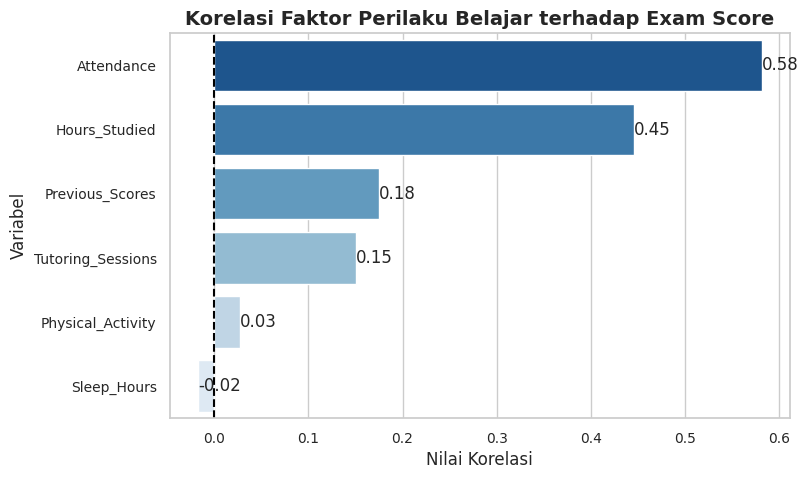

In [ ]:
# korelasi faktor belajar terhadap exam_score
plt.figure(figsize=(8,5))

sns.barplot(
    x=corr_sorted.values,
    y=corr_sorted.index,
    palette="Blues_r"
)

add_title_labels(
    "Korelasi Faktor Perilaku Belajar terhadap Exam Score",
    "Nilai Korelasi",
    "Variabel"
)

for i, v in enumerate(corr_sorted.values):
    plt.text(v, i, f"{v:.2f}", va='center')

plt.axvline(0, color='black', linestyle='--')
plt.show()

### **Insight - Faktor Numerik terhadap Exam Score**

- **Attendance (0.58)** dan **Hours_Studied (0.45)** merupakan dua faktor dengan korelasi paling kuat terhadap nilai ujian, menunjukkan bahwa kehadiran dan intensitas belajar adalah penentu utama performa akademik.

- **Previous_Scores (0.18)** dan **Tutoring_Sessions (0.15)** memiliki pengaruh yang lebih lemah, sehingga berperan sebagai faktor pendukung, bukan penentu utama.

- **Sleep_Hours (-0.02)** dan **Physical_Activity (0.03)** hampir tidak menunjukkan hubungan linear dengan nilai ujian.

**Kesimpulan:**
Performa akademik siswa terutama dipengaruhi oleh **konsistensi kehadiran dan jam belajar**, sementara faktor lainnya memiliki kontribusi yang relatif kecil.

/tmp/ipykernel_244/3035034027.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipykernel_244/3035034027.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipykernel_244/3035034027.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(
/tmp/ipykernel_244/3035034027.py:5: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.barplot(
/tmp/ipykernel_244/3035034027.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.barplot(


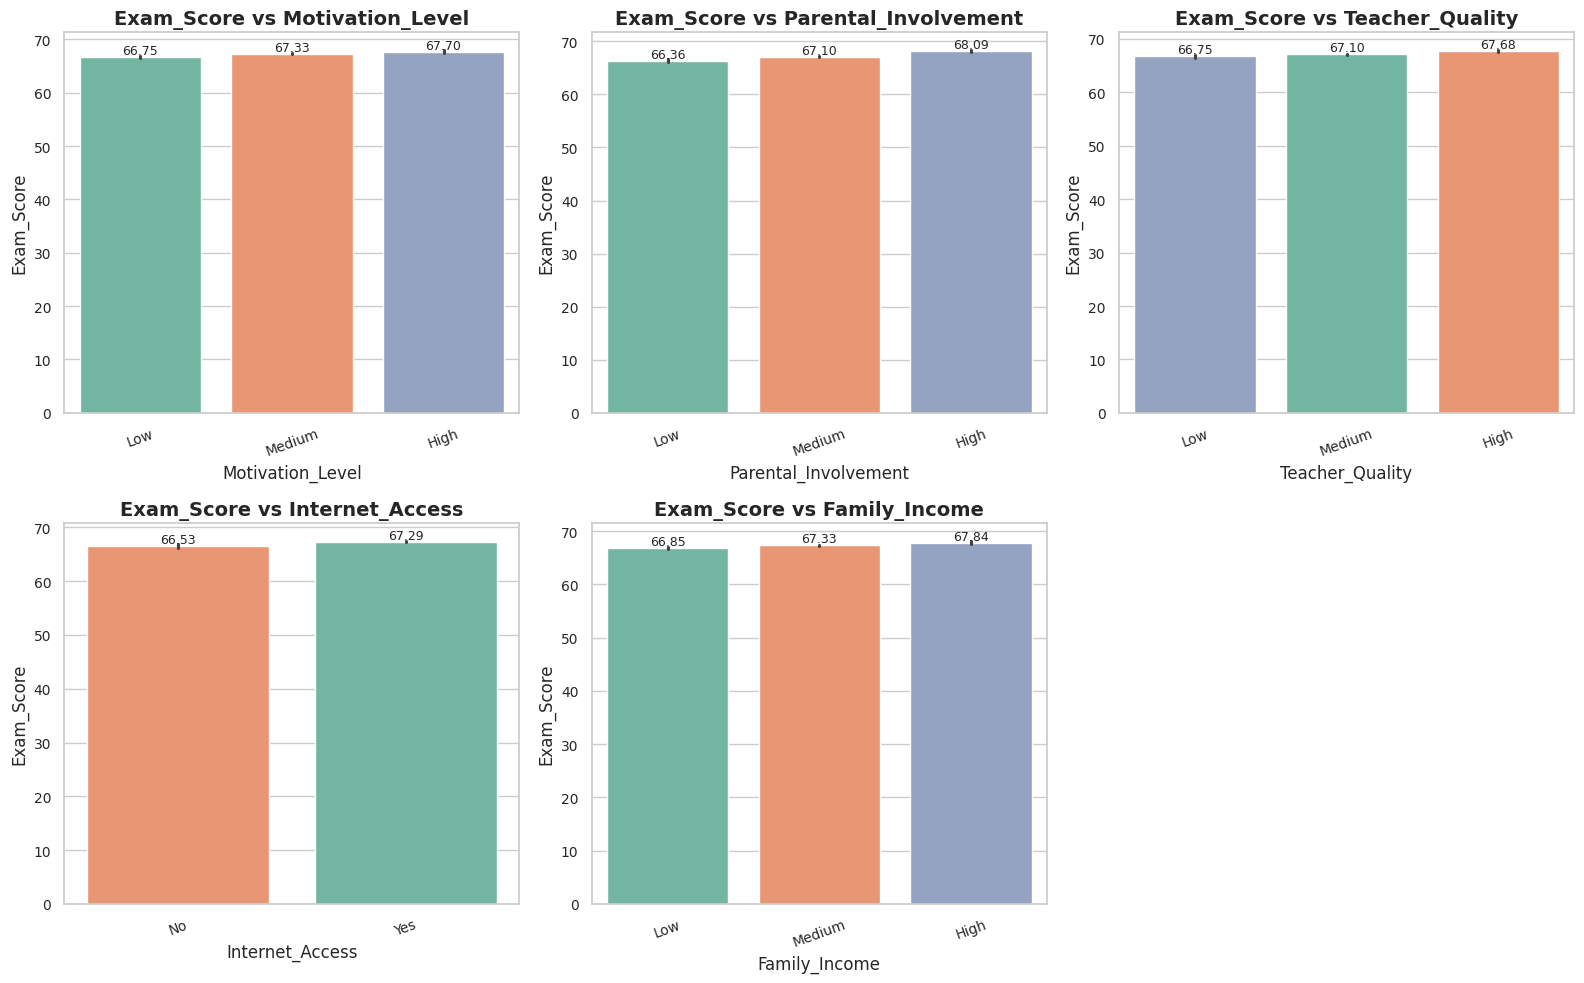

In [ ]:
cat_cols = [
    'Motivation_Level',
    'Parental_Involvement',
    'Teacher_Quality',
    'Internet_Access',
    'Family_Income'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    barplot_with_values(df, col, 'Exam_Score', axes[i])

# hapus subplot kosong kalau ada
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### **Insight - Faktor Kategorikal terhadap Exam Score**

- Seluruh variabel kategorikal (**Motivation_Level, Parental_Involvement, Teacher_Quality, Family_Income**) menunjukkan pola yang konsisten: kategori **High** memiliki rata-rata nilai tertinggi, diikuti Medium dan Low.

- Namun, selisih antar kategori relatif kecil (sekitar ±1 poin), sehingga pengaruhnya tidak sekuat variabel numerik seperti attendance dan jam belajar.

- **Internet_Access** menunjukkan perbedaan yang sangat tipis antara Yes dan No, mengindikasikan bahwa akses internet tidak memberikan dampak langsung yang signifikan terhadap nilai ujian.

**Kesimpulan:**
Faktor kategorikal cenderung berperan sebagai **faktor pendukung**, bukan penentu utama, dalam performa akademik siswa.

## **🎯 BQ2 — Pengaruh Keterlibatan Orang Tua terhadap Exam Score**

Analisis ini bertujuan untuk mengevaluasi pengaruh tingkat keterlibatan orang tua (*Parental Involvement*) terhadap performa akademik siswa (*Exam Score*).

Pendekatan yang digunakan:

* Menghitung rata-rata nilai ujian untuk setiap kategori keterlibatan orang tua
* Membandingkan perbedaan antar kelompok
* Mengamati variasi data menggunakan error bar (standar deviasi)

Analisis ini penting karena:

* Keterlibatan orang tua merupakan faktor eksternal yang dapat memengaruhi motivasi dan disiplin belajar siswa
* Hasilnya dapat digunakan sebagai dasar rekomendasi intervensi berbasis keluarga dalam sistem EduPredict AI


/tmp/ipykernel_244/253300381.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_244/253300381.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(


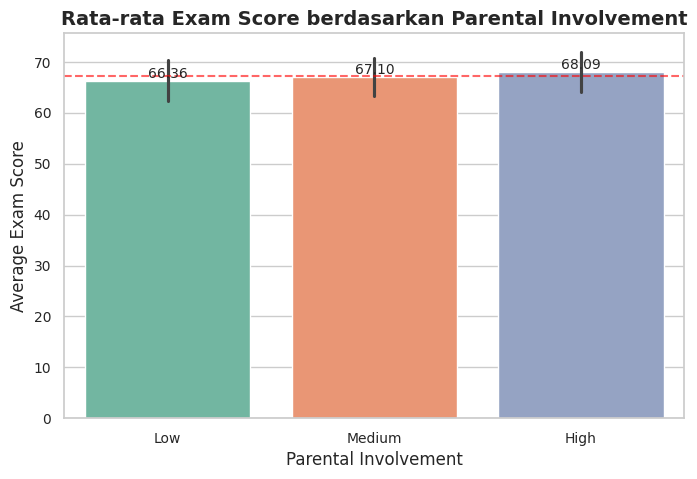

In [ ]:
plt.figure(figsize=(8,5))

order = df.groupby('Parental_Involvement')['Exam_Score'].mean().sort_values().index

ax = sns.barplot(
    data=df,
    x='Parental_Involvement',
    y='Exam_Score',
    order=order,
    palette=cat_palette,
    errorbar='sd'
)

# Tambahkan angka
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

# Garis rata-rata global
mean_score = df['Exam_Score'].mean()
ax.axhline(mean_score, linestyle='--', color='red', alpha=0.6)

add_title_labels(
    "Rata-rata Exam Score berdasarkan Parental Involvement",
    "Parental Involvement",
    "Average Exam Score"
)

plt.show()

### **Insight - Pengaruh Keterlibatan Orang Tua**

Rata-rata Exam Score menunjukkan tren peningkatan seiring meningkatnya tingkat *Parental Involvement*. Siswa dengan keterlibatan orang tua kategori *High* memiliki rata-rata nilai tertinggi (68.09), diikuti kategori *Medium* (67.10), dan *Low* (66.36).

Meskipun terdapat pola kenaikan yang konsisten, selisih rata-rata antar kelompok relatif kecil. Hal ini mengindikasikan bahwa keterlibatan orang tua memiliki hubungan positif terhadap performa akademik, namun bukan merupakan faktor dominan utama dibanding variabel seperti Attendance atau Hours_Studied.

Temuan ini menunjukkan bahwa dukungan keluarga tetap berperan sebagai faktor pendukung dalam menjaga performa akademik siswa, terutama dalam membangun lingkungan belajar yang lebih stabil dan suportif.

/tmp/ipykernel_244/1189434450.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_244/1189434450.py:3: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.boxplot(


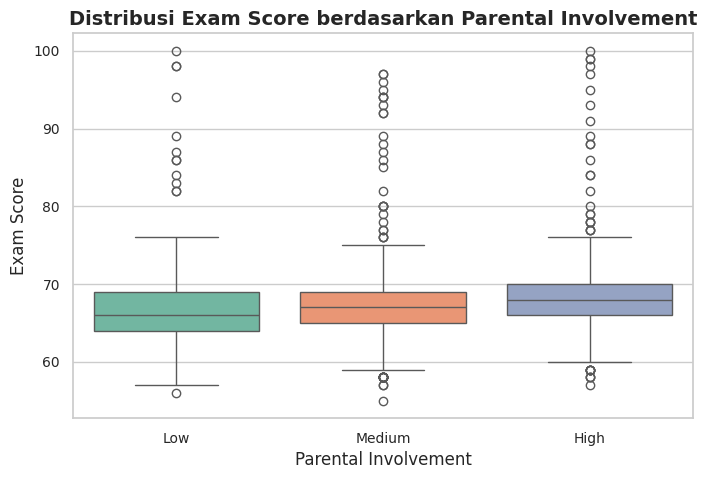

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Parental_Involvement',
    y='Exam_Score',
    palette=cat_palette
)

add_title_labels(
    "Distribusi Exam Score berdasarkan Parental Involvement",
    "Parental Involvement",
    "Exam Score"
)

plt.show()

### **Insight - Distribusi Exam Score berdasarkan Keterlibatan Orang Tua**

Distribusi Exam Score pada setiap kategori *Parental Involvement* menunjukkan pola median yang cenderung meningkat dari kategori *Low* ke *High*. Kelompok dengan keterlibatan orang tua tinggi memiliki median nilai yang sedikit lebih baik dibanding kelompok lainnya.

Sebaran data antar kelompok terlihat relatif mirip, dengan rentang nilai utama yang tidak berbeda jauh. Hal ini mengindikasikan bahwa keterlibatan orang tua memiliki hubungan positif terhadap performa akademik, namun pengaruhnya cenderung moderat dan tidak menjadi satu-satunya faktor penentu hasil ujian siswa.

Selain itu, keberadaan beberapa outlier pada seluruh kategori menunjukkan bahwa terdapat siswa dengan performa sangat tinggi maupun rendah di setiap tingkat keterlibatan orang tua. Temuan ini memperlihatkan bahwa performa akademik tetap dipengaruhi oleh kombinasi berbagai faktor lain seperti kehadiran, intensitas belajar, dan motivasi belajar siswa.

## **🎯 BQ3 — Pengaruh Motivation Level terhadap Perilaku Belajar**

Analisis ini bertujuan untuk mengevaluasi bagaimana tingkat motivasi siswa (*Motivation Level*) memengaruhi perilaku belajar, khususnya dalam hal:

* Jumlah jam belajar (*Hours Studied*)
* Tingkat kehadiran (*Attendance*)

Pendekatan yang digunakan:

* Menghitung rata-rata setiap variabel perilaku berdasarkan kategori motivasi
* Membandingkan pola antar kelompok
* Menggunakan visualisasi untuk melihat tren peningkatan atau penurunan

Analisis ini penting karena:
Motivasi merupakan faktor internal yang berpotensi memengaruhi kebiasaan belajar siswa, yang pada akhirnya berdampak pada performa akademik.

/tmp/ipykernel_244/1063635184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_244/1063635184.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(


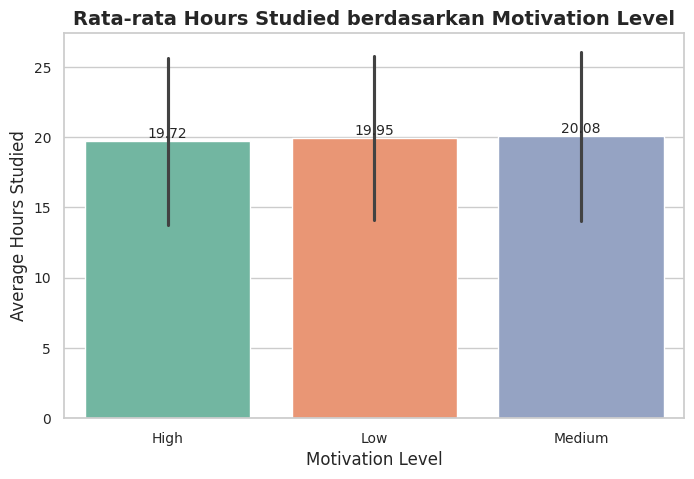

In [ ]:
plt.figure(figsize=(8,5))

order = df.groupby('Motivation_Level')['Hours_Studied'].mean().sort_values().index

ax = sns.barplot(
    data=df,
    x='Motivation_Level',
    y='Hours_Studied',
    order=order,
    palette=cat_palette,
    errorbar='sd'
)

# Tambahkan angka
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

add_title_labels(
    "Rata-rata Hours Studied berdasarkan Motivation Level",
    "Motivation Level",
    "Average Hours Studied"
)

plt.show()

### **Insight - Pengaruh Level Motivasi Terhadap Jam Belajar**

Rata-rata *Hours Studied* pada setiap kategori *Motivation Level* menunjukkan perbedaan yang relatif kecil. Kelompok dengan motivasi *Medium* memiliki rata-rata jam belajar tertinggi (20.08 jam), diikuti *Low* (19.95 jam) dan *High* (19.72 jam).

Pola ini menunjukkan bahwa tingkat motivasi pada dataset tidak memiliki hubungan yang terlalu kuat terhadap durasi belajar siswa. Meskipun motivasi sering dianggap berkaitan dengan kebiasaan belajar, hasil visualisasi mengindikasikan bahwa jumlah jam belajar antar kelompok motivasi cenderung stabil dan tidak berbeda secara mencolok.

Temuan ini mengisyaratkan bahwa motivasi kemungkinan lebih berperan terhadap kualitas atau konsistensi belajar dibanding sekadar total waktu belajar yang dicatat dalam dataset.

/tmp/ipykernel_244/3359917977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_244/3359917977.py:5: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  ax = sns.barplot(


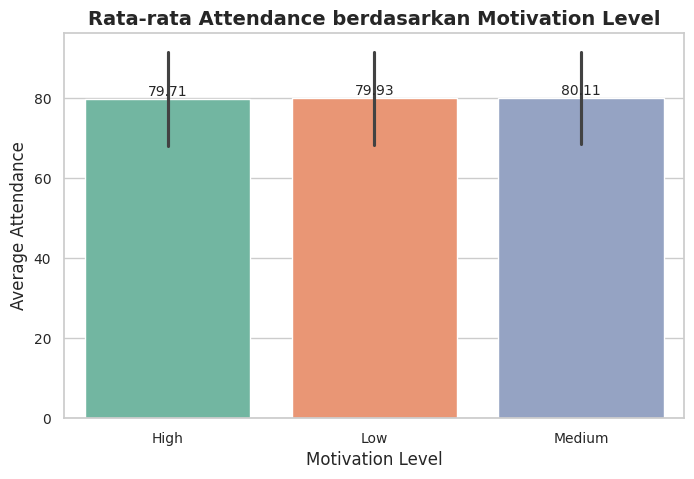

In [ ]:
plt.figure(figsize=(8,5))

order = df.groupby('Motivation_Level')['Attendance'].mean().sort_values().index

ax = sns.barplot(
    data=df,
    x='Motivation_Level',
    y='Attendance',
    order=order,
    palette=cat_palette,
    errorbar='sd'
)

# Tambahkan angka
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

add_title_labels(
    "Rata-rata Attendance berdasarkan Motivation Level",
    "Motivation Level",
    "Average Attendance"
)

plt.show()

### **Insight - Pengaruh Level Motivasi Terhadap Kehadiran**

Rata-rata *Attendance* pada seluruh kategori *Motivation Level* menunjukkan nilai yang relatif tinggi dan stabil, dengan perbedaan antar kelompok yang sangat kecil. Kelompok motivasi *Medium* memiliki rata-rata kehadiran tertinggi (80.11%), diikuti *Low* (79.93%) dan *High* (79.71%).

Hasil ini mengindikasikan bahwa tingkat motivasi dalam dataset tidak menunjukkan hubungan yang kuat terhadap tingkat kehadiran siswa. Pola kehadiran terlihat cukup konsisten pada seluruh kategori motivasi tanpa adanya perbedaan yang signifikan.

Temuan ini menunjukkan bahwa faktor motivasi kemungkinan tidak secara langsung memengaruhi kehadiran siswa, atau terdapat faktor lain yang lebih dominan dalam menentukan konsistensi kehadiran, seperti aturan sekolah, lingkungan belajar, maupun faktor eksternal lainnya.

## **🎯 BQ4 — Pengaruh Faktor Sosial-Ekonomi Terhadap Siswa yang Berisiko Tinggi**


Analisis ini bertujuan untuk mengidentifikasi seberapa besar pengaruh faktor sosial-ekonomi seperti akses internet dan pendapatan keluarga terhadap siswa yang berada dalam kategori risiko akademik tinggi (*High Risk*).


Pendekatan yang digunakan:


* Memfilter data siswa dengan kategori risiko tinggi.
* Menghitung persentase siswa yang berasal dari keluarga berpendapatan rendah.
* Menghitung persentase siswa yang tidak memiliki akses internet.
* Membandingkan kedua faktor untuk mengetahui faktor sosial-ekonomi yang paling dominan.


Hasil analisis ini akan digunakan sebagai dasar dalam:

* Mengidentifikasi kelompok siswa yang membutuhkan dukungan tambahan.
* Menyusun program bantuan pendidikan dan akses teknologi.
* Memprioritaskan intervensi bagi siswa dengan hambatan ekonomi dan digital.


/tmp/ipykernel_244/1143239971.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


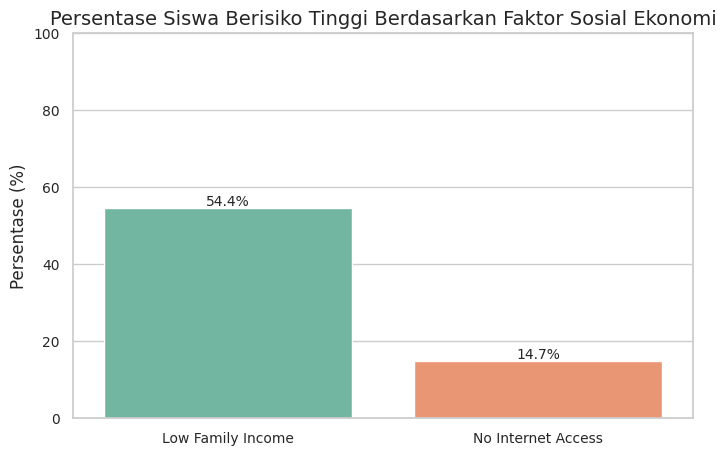

In [ ]:
sns.set_style("whitegrid")
high_risk = df[df['Risk_Category'] == 'High']

low_income_pct = (high_risk['Family_Income'] == 'Low').mean() * 100
no_internet_pct = (high_risk['Internet_Access'] == 'No').mean() * 100

bq4_data = pd.DataFrame({
    'Factor': ['Low Family Income', 'No Internet Access'],
    'Percentage': [low_income_pct, no_internet_pct]
})

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=bq4_data,
    x='Factor',
    y='Percentage',
    palette='Set2'
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)


plt.title("Persentase Siswa Berisiko Tinggi Berdasarkan Faktor Sosial Ekonomi")
plt.xlabel('')
plt.ylabel('Persentase (%)')
plt.ylim(0, 100)
plt.show()

### **Insight - Pengaruh Faktor Sosial Ekonomi Terhadap Siswa Berisiko Tinggi**

Pada kelompok siswa dengan kategori *High Risk*, faktor pendapatan keluarga rendah terlihat lebih dominan dibanding keterbatasan akses internet. Sebanyak 54.4% siswa berisiko tinggi berasal dari kategori *Low Family Income*, sedangkan siswa tanpa akses internet berada pada angka 14.7%.

Temuan ini mengindikasikan bahwa kondisi ekonomi keluarga memiliki hubungan yang lebih kuat terhadap risiko akademik dibanding faktor akses internet pada dataset ini. Keterbatasan ekonomi kemungkinan memengaruhi berbagai aspek pendukung belajar, seperti stabilitas lingkungan belajar, akses sumber belajar tambahan, maupun dukungan akademik di luar sekolah.

Sementara itu, persentase siswa tanpa akses internet yang relatif lebih rendah menunjukkan bahwa akses digital bukan faktor dominan utama pada kelompok risiko tinggi, meskipun tetap relevan sebagai bagian dari konteks sosial-ekonomi siswa.

## **🎯 BQ5 — Pengaruh Kualitas Guru Terhadap Performa Akademik dan Risiko Siswa**


Analisis ini bertujuan untuk mengevaluasi bagaimana kualitas guru memengaruhi performa akademik siswa serta distribusi tingkat risiko akademik.


Pendekatan yang digunakan:


* Menghitung rata-rata nilai ujian berdasarkan tingkat kualitas guru.
* Menganalisis distribusi kategori risiko pada setiap kelompok kualitas guru.
* Membandingkan pola performa dan risiko antar kategori guru.

Hasil analisis ini akan digunakan sebagai dasar dalam:

* Menentukan pentingnya variabel kualitas guru dalam model prediksi.
* Mendukung evaluasi dan pengembangan kompetensi tenaga pengajar.
* Merancang strategi peningkatan kualitas pembelajaran di sekolah.


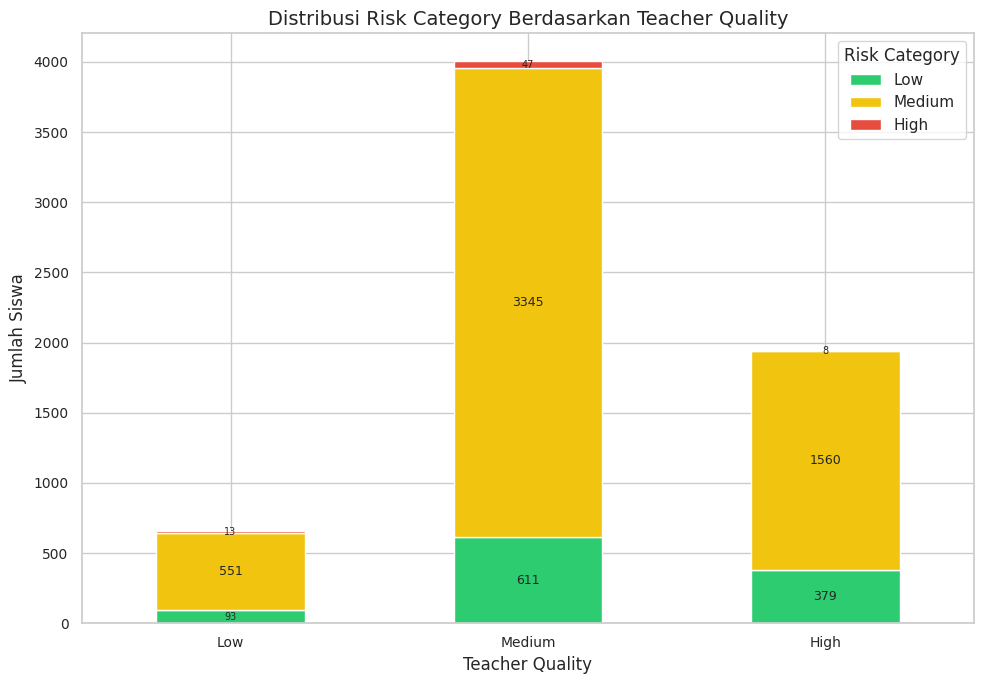

In [ ]:
risk_teacher = pd.crosstab(
    df['Teacher_Quality'],
    df['Risk_Category']
)

risk_teacher = risk_teacher.loc[['Low', 'Medium', 'High']]
risk_teacher = risk_teacher[['Low', 'Medium', 'High']]

ax = risk_teacher.plot(
    kind='bar',
    stacked=True,
    figsize=(10,7),
    color=[risk_palette['Low'], risk_palette['Medium'], risk_palette['High']]
)

for i in range(len(risk_teacher)):
    cum = 0
    for j, col in enumerate(risk_teacher.columns):
        val = risk_teacher.iloc[i, j]

        if val > 0:
            current_fontsize = 9
            if val < 200:
                current_fontsize = 7

            ax.text(
                i,
                cum + val/2,
                f'{int(val)}',
                ha='center',
                va='center',
                fontsize=current_fontsize
            )

        cum += val

plt.title('Distribusi Risk Category Berdasarkan Teacher Quality')
plt.xlabel('Teacher Quality')
plt.ylabel('Jumlah Siswa')
plt.legend(title='Risk Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **Insight - Distribusi Risk Category Berdasarkan Kualitas Guru**

Distribusi *Risk Category* pada setiap tingkat *Teacher Quality* menunjukkan bahwa mayoritas siswa berada pada kategori risiko *Medium* di seluruh kelompok kualitas guru. Kategori *High Risk* memiliki jumlah yang relatif kecil pada semua kelompok.

Kelompok dengan *Teacher Quality* kategori *Medium* memiliki jumlah siswa terbanyak secara keseluruhan, sehingga distribusi risiko pada kategori ini juga terlihat paling tinggi secara absolut. Sementara itu, kelompok *High Teacher Quality* menunjukkan proporsi siswa risiko rendah yang relatif lebih besar dibanding kategori lainnya.

Secara umum, visualisasi ini mengindikasikan bahwa kualitas guru memiliki hubungan terhadap distribusi risiko akademik siswa, namun pola perbedaannya tidak terlihat terlalu ekstrem. Temuan ini menunjukkan bahwa kualitas pengajaran kemungkinan berperan sebagai faktor pendukung dalam menjaga performa akademik dan stabilitas risiko siswa, bersama faktor lain seperti kehadiran, motivasi, dan intensitas belajar.

## **🎯 BQ6 — Profil Dominan Siswa Berisiko Tinggi**


Analisis ini bertujuan untuk mengidentifikasi kombinasi karakteristik yang paling sering muncul pada siswa dengan risiko akademik tinggi.


Pendekatan yang digunakan:


* Memfilter siswa dengan kategori High Risk.
* Menganalisis distribusi variabel kategorikal utama, seperti motivasi, keterlibatan orang tua, pendapatan keluarga, akses internet, dan kualitas guru.
* Mengidentifikasi pola karakteristik yang paling dominan.

Hasil analisis ini akan digunakan sebagai dasar dalam:

* Membentuk profil siswa berisiko tinggi secara komprehensif.
* Mengembangkan sistem peringatan dini yang lebih akurat.
* Menyusun rekomendasi intervensi yang lebih personal dan tepat sasaran.


/tmp/ipykernel_244/309862921.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


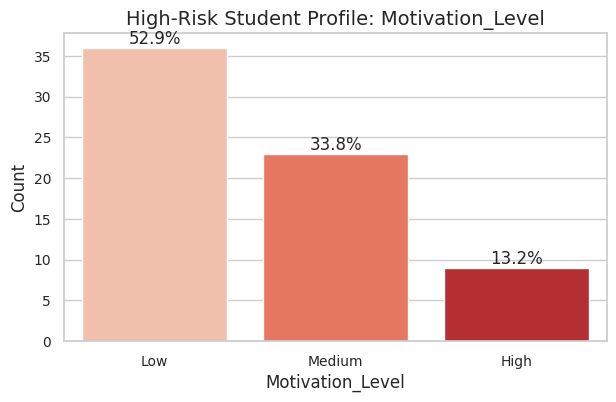

/tmp/ipykernel_244/309862921.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


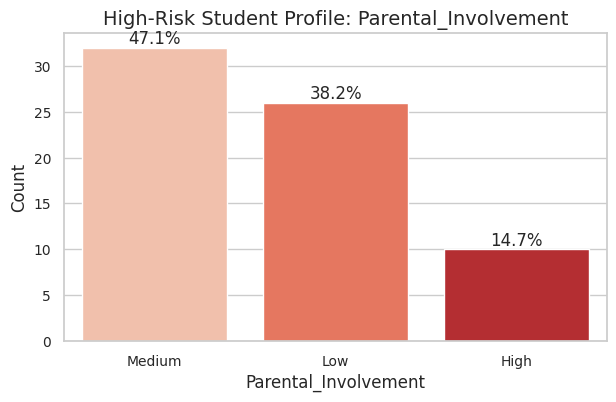

/tmp/ipykernel_244/309862921.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


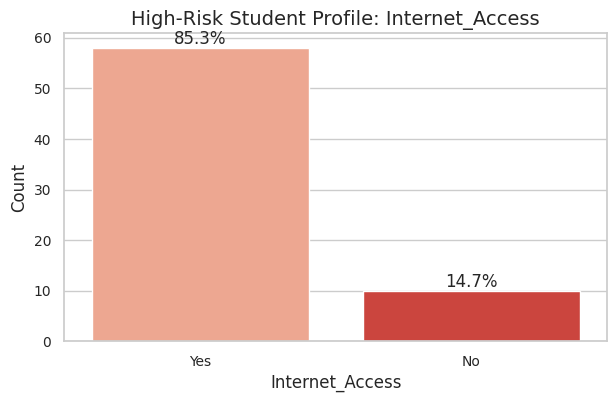

/tmp/ipykernel_244/309862921.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


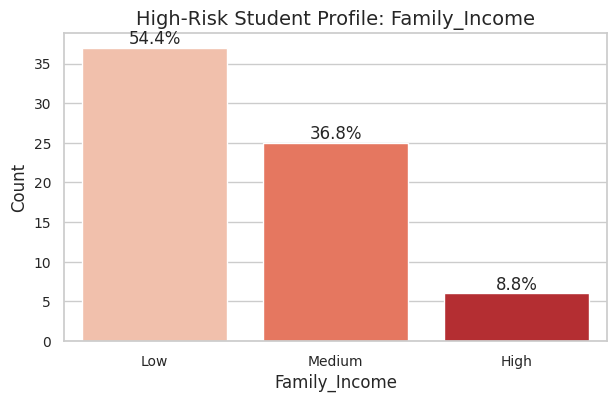

/tmp/ipykernel_244/309862921.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


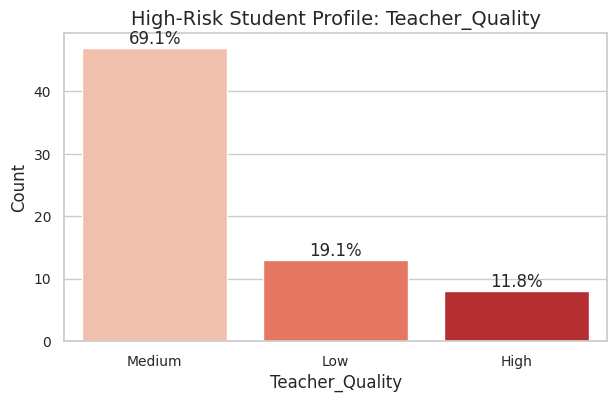

In [ ]:
high_risk = df[df['Risk_Category'] == 'High']

# Profil kategorikal
profile_cols = [
    'Motivation_Level',
    'Parental_Involvement',
    'Internet_Access',
    'Family_Income',
    'Teacher_Quality'
]

for col in profile_cols:
    plt.figure(figsize=(7,4))

    order = high_risk[col].value_counts().index

    ax = sns.countplot(
        data=high_risk,
        x=col,
        order=order,
        palette='Reds'
    )
    total = len(high_risk)
    for p in ax.patches:
        percentage = 100 * p.get_height() / total
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom')

    plt.title(f'High-Risk Student Profile: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

### **Insight - Kombinasi Faktor Siswa Profil High Risk**

Profil siswa dengan kategori *High Risk* menunjukkan pola yang cukup konsisten pada beberapa faktor perilaku dan lingkungan belajar. Mayoritas siswa berisiko tinggi memiliki *Motivation Level* rendah (52.9%), keterlibatan orang tua pada kategori *Medium* hingga *Low* (85.3%), serta berasal dari keluarga dengan pendapatan rendah hingga menengah, di mana kategori *Low Family Income* menjadi yang paling dominan (54.4%).

Pada faktor lingkungan sekolah, sebagian besar siswa *High Risk* berada pada kategori *Teacher Quality* menengah (69.1%). Hal ini menunjukkan bahwa risiko akademik tidak hanya muncul pada lingkungan belajar dengan kualitas pengajaran rendah, tetapi juga dapat terjadi pada kondisi pembelajaran yang relatif normal ketika didukung faktor lain seperti motivasi belajar dan kondisi sosial-ekonomi.

Menariknya, mayoritas siswa berisiko tinggi tetap memiliki akses internet (85.3%). Temuan ini mengindikasikan bahwa keterbatasan akses digital bukan faktor dominan utama pada kelompok risiko tinggi dalam dataset ini. Sebaliknya, pola risiko lebih banyak berkaitan dengan kombinasi motivasi belajar, dukungan keluarga, dan kondisi ekonomi siswa.

Secara keseluruhan, hasil analisis menunjukkan bahwa siswa berisiko tinggi cenderung memiliki karakteristik multidimensional, sehingga pendekatan intervensi tidak cukup hanya berfokus pada aspek akademik, tetapi juga perlu mempertimbangkan dukungan keluarga, motivasi belajar, dan kondisi sosial-ekonomi siswa secara lebih menyeluruh.

# 📌 **Kesimpulan Akhir Business Questions Analysis**

Berdasarkan keseluruhan exploratory dan explanatory analysis pada dataset EduPredict AI, ditemukan bahwa faktor perilaku belajar merupakan indikator yang paling konsisten berkaitan dengan performa akademik siswa. Variabel `Attendance` dan `Hours_Studied` menunjukkan korelasi positif tertinggi terhadap `Exam_Score`, sehingga keduanya dapat dipertimbangkan sebagai sinyal utama dalam sistem *Early Warning* untuk mendeteksi potensi risiko akademik lebih dini.

Pada faktor lingkungan belajar dan dukungan eksternal, variabel seperti `Parental_Involvement`, `Motivation_Level`, dan `Teacher_Quality` menunjukkan tren hubungan positif terhadap performa akademik. Siswa dengan keterlibatan orang tua lebih tinggi, motivasi belajar yang lebih baik, serta kualitas guru yang lebih baik cenderung memiliki rata-rata nilai yang sedikit lebih tinggi. Namun, perbedaan antar kelompok relatif moderat sehingga faktor-faktor tersebut lebih berperan sebagai faktor pendukung dibanding penentu utama performa akademik.

Analisis perilaku belajar berdasarkan `Motivation_Level` menunjukkan bahwa perbedaan rata-rata `Hours_Studied` dan `Attendance` antar kategori motivasi relatif kecil. Temuan ini mengindikasikan bahwa motivasi pada dataset tidak menunjukkan hubungan langsung yang kuat terhadap durasi belajar maupun tingkat kehadiran siswa, meskipun tetap relevan sebagai bagian dari profil perilaku akademik.

Dari sisi sosial-ekonomi, siswa dengan kategori `High Risk` lebih banyak berasal dari kelompok `Low Family Income`. Sebaliknya, mayoritas siswa berisiko tinggi tetap memiliki akses internet, sehingga keterbatasan akses digital tidak tampak sebagai karakteristik dominan pada kelompok *High Risk* dalam dataset ini. Temuan ini menunjukkan bahwa kondisi ekonomi keluarga kemungkinan memiliki hubungan yang lebih luas terhadap risiko akademik dibanding sekadar akses teknologi.

Distribusi `Risk_Category` berdasarkan `Teacher_Quality` menunjukkan bahwa mayoritas siswa berada pada kategori risiko *Medium* di seluruh kelompok kualitas guru. Meskipun siswa dengan kualitas guru lebih baik cenderung memiliki proporsi risiko rendah yang lebih besar, pola perbedaannya tidak terlihat terlalu ekstrem. Hal ini mengindikasikan bahwa kualitas guru berperan sebagai faktor pendukung dalam menjaga stabilitas performa akademik siswa.

Profil siswa `High Risk` menunjukkan pola multidimensional yang cukup konsisten, yaitu dominasi `Motivation_Level` rendah, `Parental_Involvement` pada tingkat rendah hingga menengah, serta `Family_Income` rendah. Temuan ini memperlihatkan bahwa risiko akademik tidak terbentuk dari satu faktor tunggal, melainkan kombinasi antara perilaku belajar, dukungan keluarga, dan kondisi sosial-ekonomi siswa.

Secara keseluruhan, hasil analisis mendukung pendekatan *Early Warning System* yang tidak hanya berfokus pada nilai akhir siswa, tetapi juga pada pola perilaku belajar dan faktor pendukung di lingkungan siswa. Insight ini dapat dimanfaatkan sebagai dasar pengembangan dashboard monitoring, rekomendasi intervensi akademik, serta pengembangan model prediksi risiko akademik pada EduPredict AI.

# **🧪 A/B *Testing Analysis* : Pengaruh *Attendance* terhadap *Exam Score***

Pada tahap ini dilakukan analisis A/B Testing untuk mengetahui apakah terdapat perbedaan performa akademik siswa berdasarkan tingkat kehadiran (*Attendance*). Data dibagi menjadi dua kelompok, yaitu siswa dengan *Attendance* rendah dan tinggi berdasarkan nilai median, kemudian dilakukan pengujian menggunakan *Independent T-Test* untuk menganalisis apakah terdapat perbedaan rata-rata *Exam Score* yang signifikan secara statistik antara kedua kelompok tersebut.

## Hipotesis

H0: Tidak ada perbedaan Exam Score berdasarkan Attendance

H1: Ada perbedaan Exam Score berdasarkan Attendance

In [ ]:
median_attendance = df['Attendance'].median()
A = df[df['Attendance'] <= median_attendance]['Exam_Score']
B = df[df['Attendance'] > median_attendance]['Exam_Score']
print("Jumlah Grup A :", len(A))
print("Jumlah Grup B :", len(B))

Jumlah Grup A : 3423
Jumlah Grup B : 3184


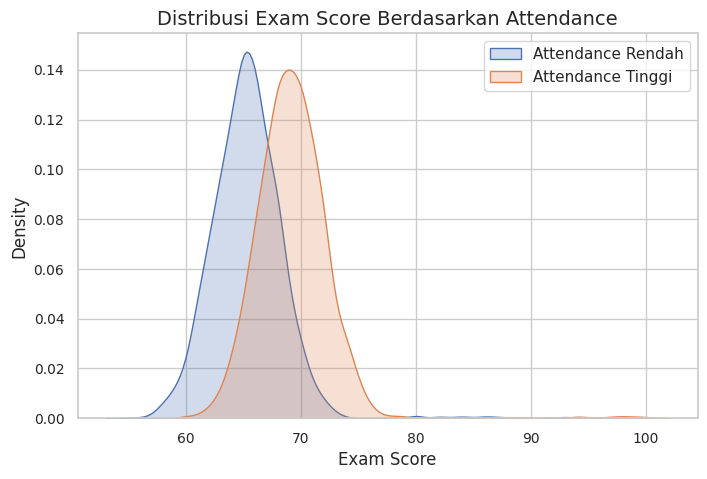

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(A, label='Attendance Rendah', fill=True)
sns.kdeplot(B, label='Attendance Tinggi', fill=True)

plt.title('Distribusi Exam Score Berdasarkan Attendance')
plt.xlabel('Exam Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
print("H0 : Tidak ada perbedaan Exam Score berdasarkan Attendance")
print("H1 : Ada perbedaan Exam Score berdasarkan Attendance")

H0 : Tidak ada perbedaan Exam Score berdasarkan Attendance
H1 : Ada perbedaan Exam Score berdasarkan Attendance


In [ ]:
shapiro_A = stats.shapiro(A)
shapiro_B = stats.shapiro(B)

print("\nNormalitas Grup A :", shapiro_A)
print("Normalitas Grup B :", shapiro_B)


Normalitas Grup A : ShapiroResult(statistic=np.float64(0.8555417285818825), pvalue=np.float64(1.5360171960431362e-48))
Normalitas Grup B : ShapiroResult(statistic=np.float64(0.8257948673547191), pvalue=np.float64(2.4349073896745045e-50))


In [ ]:
levene_test = stats.levene(A, B)

print("\nLevene Test :", levene_test)


Levene Test : LeveneResult(statistic=np.float64(0.08800157794114184), pvalue=np.float64(0.7667426037117963))


In [ ]:
ttest = stats.ttest_ind(A, B, equal_var=True)

print("\nT-Statistic :", ttest.statistic)
print("P-Value     :", ttest.pvalue)


T-Statistic : -46.687588719575736
P-Value     : 0.0


In [ ]:
alpha = 0.05

if ttest.pvalue < alpha:
    print("Tolak H0")
    print("Terdapat perbedaan signifikan Exam Score berdasarkan Attendance")
else:
    print("Gagal Tolak H0")
    print("Tidak terdapat perbedaan signifikan Exam Score berdasarkan Attendance")

Tolak H0
Terdapat perbedaan signifikan Exam Score berdasarkan Attendance


## Interpretasi

Berdasarkan hasil *Independent T-Test*, diperoleh keputusan untuk menolak H0 karena nilai *p-value* lebih kecil dari 0.05. Hasil ini menunjukkan bahwa terdapat perbedaan rata-rata *Exam Score* yang signifikan antara kelompok siswa dengan tingkat *Attendance* rendah dan tinggi. Siswa dengan tingkat kehadiran tinggi memiliki rata-rata nilai ujian yang lebih baik dibandingkan siswa dengan tingkat kehadiran rendah.